## Этап 0 — Подготовка

Я создала структуру проекта, подключила виртуальное окружение .venv и запустила библиотеки, которые могут понадобиться. Проверила, что файл датасета существует по ожидаемому пути, и зафиксировала версию Python и платформу.

In [1]:
import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
from sklearn.cluster import KMeans
print("ok")

ok


In [2]:
from pathlib import Path

p = Path("../data/raw/sorted_cheese_top.tsv")

In [3]:
DATA_PATH = Path("..") / "data" / "raw" / "sorted_cheese_top.tsv"

print("Data path exists:", DATA_PATH.exists())
print("Data path:", DATA_PATH.resolve())

pl.Config.set_tbl_rows(20)
pl.Config.set_tbl_cols(30)
pl.Config.set_fmt_str_lengths(120)

Data path exists: True
Data path: /Users/evaeva.monsher/Desktop/karat_violette/data/raw/sorted_cheese_top.tsv


polars.config.Config

## Этап 1 — Первичное чтение

На этом этапе я проверяю формат файла и заголовки, читаю небольшую выборку строк и фиксирую фактическую схему датасета, уточняя формат типы полей.

Для чтения небольшой выборки строк используется библиотека polars и функция pl.read_csv с указанием табуляции как разделителя. Этот подход позволяет увидеть имена колонок и типы, а также убедиться, что парсинг файла настроен корректно.

Визуально оценю, что имею, чтобы увидеть форматы записи, примерно составить дальнейший план действий по очистке и обогащению.

In [4]:
p = Path("../data/raw/sorted_cheese_top.tsv")

## Этап 2 - Типизирование

На этом этапе я типизирую датасет и провожу контроль качества, чтобы получить стабильную таблицу с едиными типами и инвариантами, на которой дальше уже буду считать витрины и метрики без повторного парсинга.

Описываю соответствие исходных колонок каноническим именам для единообазия (Так привычнее работать и меньше шансов запутаться в именах).

In [5]:
CANON = {
    "user_id": "user_id",
    "buyer_id": "user_id",
    "user_synth_id": "id",
    "ts": "date_actual",
    "product_name": "title",
    "amount": "sum",
    "qty": "quantity",
    "is_marketplace": "is_mm",
    "check_id": "check_id",
}

Считываю файл лениво (polars), переименовываю колонки и привожу типы.

In [6]:
lf = pl.scan_csv(
    DATA_PATH,
    separator="\t",
    infer_schema_length=0,
)

lf_typed = (
    lf.rename({
        CANON["buyer_id"]: "buyer_id",
        CANON["user_synth_id"]: "user_synth_id",
        CANON["ts"]: "ts",
        CANON["product_name"]: "product_name",
        CANON["amount"]: "amount",
        CANON["qty"]: "qty",
        CANON["is_marketplace"]: "is_marketplace",
        CANON["check_id"]: "check_id",
    })
    .with_columns(
        pl.col("buyer_id").cast(pl.Utf8, strict=False),
        pl.col("user_synth_id").cast(pl.Utf8, strict=False),
        pl.col("check_id").cast(pl.Utf8, strict=False),
        pl.col("product_name").cast(pl.Utf8, strict=False).str.strip_chars(),
        pl.col("amount").cast(pl.Float64, strict=False),
        pl.col("qty").cast(pl.Float64, strict=False),
        pl.col("ts")
          .cast(pl.Utf8, strict=False)
          .str.strip_chars()
          .str.strptime(pl.Datetime, format="%Y-%m-%d %H:%M:%S%.f", strict=False)
          .alias("ts"),
        pl.col("is_marketplace")
          .cast(pl.Utf8, strict=False)
          .str.strip_chars()
          .str.to_lowercase()
          .map_elements(lambda x: True if x in ("true", "1", "t", "yes") else (False if x in ("false", "0", "f", "no") else None),
                        return_dtype=pl.Boolean)
          .alias("is_marketplace"),
    )
)

Сводные показатели качества по ключам и диапазонам, чтобы увидеть пропуски и аномалии.

In [7]:
qc = lf_typed.select(
    pl.len().alias("rows"),
    pl.col("buyer_id").null_count().alias("null_buyer_id"),
    pl.col("user_synth_id").null_count().alias("null_user_synth_id"),
    pl.col("check_id").null_count().alias("null_check_id"),
    pl.col("ts").null_count().alias("null_ts"),
    pl.col("product_name").null_count().alias("null_product_name"),
    pl.col("amount").null_count().alias("null_amount"),
    pl.col("qty").null_count().alias("null_qty"),
    pl.col("is_marketplace").null_count().alias("null_is_marketplace"),
    pl.col("amount").min().alias("amount_min"),
    pl.col("amount").max().alias("amount_max"),
    pl.col("qty").min().alias("qty_min"),
    pl.col("qty").max().alias("qty_max"),
    pl.col("ts").min().alias("ts_min"),
    pl.col("ts").max().alias("ts_max"),
).collect()

qc

rows,null_buyer_id,null_user_synth_id,null_check_id,null_ts,null_product_name,null_amount,null_qty,null_is_marketplace,amount_min,amount_max,qty_min,qty_max,ts_min,ts_max
u32,u32,u32,u32,u32,u32,u32,u32,u32,f64,f64,f64,f64,datetime[μs],datetime[μs]
16509165,0,0,0,0,0,0,109,0,0.0,154990.0,0.001,540.0,2023-01-01 08:04:44,2025-12-31 10:38:00


Оценка наличия дублей

In [8]:
dup = (
    lf_typed
    .group_by(["check_id", "product_name", "amount", "qty"])
    .len()
    .filter(pl.col("len") > 1)
    .select(pl.col("len").sum().alias("rows_in_duplicate_groups"),
            pl.len().alias("n_duplicate_groups"))
    .collect()
)
dup

rows_in_duplicate_groups,n_duplicate_groups
u32,u32
5970,2973


Я сначала диагностирую полные повторы строк чека (check_id, product_name, amount, qty), а затем на уровне витрины позиций агрегирую одинаковые товары внутри одного чека по (check_id, product_name), потому что для аналитической задачи одна позиция товара в чеке должна быть представлена одной строкой.


In [9]:
base_path = Path("..") / "data" / "interim" / "base_typed.parquet"
lf_typed.sink_parquet(base_path)
base_path.resolve()

PosixPath('/Users/evaeva.monsher/Desktop/karat_violette/data/interim/base_typed.parquet')

## Этап 3 - Очистка и нормализация

Общее число строк составляет 16 509 165. По ключевым полям, необходимым для построения метрик, пропуски отсутствуют, что позволяет корректно формировать витрины и выполнять агрегирования.

При этом есть особенности, требующие доп обработки. Есть 109 строк с пропущенным значением количества - скорее всего лучше убрать, хотя же может указывать и на технические процессы, оставлю в главном датасете - интересно для анализа. Минимальное значение суммы равно 0, что указывает на наличие позиций с нулевой стоимостью. Такие строки могут отражать промо или технические операции, поэтому их необходимо явно маркировать и возможно (или нет) исключить из анализа платных позиций. Минимальное значение количества равно 0.001, что возможно аномалия и требует доп проверки.

Также есть дублирующиеся позиции внутри чеков, однако их доля незначительна, и всё же надо будет проверить.

На этом этапе как раз выполню очистку и нормализацию. Будут сформулированы правила исключения строк с пропусками и некорректными значениями, добавлены календарные признаки для последующих разрезов, выполнено устранение дублей при необходимости.

Считаю масштабы потенциально проблемных значений, чтобы определить правила фильтрации.

In [10]:
qc_flags = lf_typed.select(
    pl.count().alias("rows"),
    (pl.col("qty").is_null()).sum().alias("qty_null"),
    (pl.col("qty") <= 0).sum().alias("qty_le_0"),
    (pl.col("amount").is_null()).sum().alias("amount_null"),
    (pl.col("amount") < 0).sum().alias("amount_lt_0"),
    (pl.col("amount") == 0).sum().alias("amount_eq_0"),
).collect()

qc_flags

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/1605906811.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("rows"),


rows,qty_null,qty_le_0,amount_null,amount_lt_0,amount_eq_0
u32,u32,u32,u32,u32,u32
16509165,109,0,0,0,33395


Оцениваю долю сверхмалых количеств, чтобы понять, является ли это редкой аномалией или какой-то особенностью.

In [11]:
small_qty = lf_typed.select(
    pl.count().alias("rows"),
    (pl.col("qty") < 0.01).sum().alias("qty_lt_0_01"),
    (pl.col("qty") == 0.001).sum().alias("qty_eq_0_001"),
).collect()

small_qty

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/956988925.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("rows"),


rows,qty_lt_0_01,qty_eq_0_001
u32,u32,u32
16509165,2886,2849


Визуально оцениваю товары, которые чаще всего встречаются со сверхмалыми количествами, чтобы обосновать правило обработки.

In [12]:
top_small = (
    lf_typed
    .filter(pl.col("qty") < 0.01)
    .group_by("product_name")
    .len()
    .sort("len", descending=True)
    .head(30)
    .collect()
)

top_small

product_name,len
str,u32
"""бананы""",188
"""возмещение за: бананы""",123
"""картофель""",111
"""картофель эконом""",102
"""лук репчатый""",58
"""помидоры""",54
"""возмещение за: лук репчатый""",49
"""апельсины""",49
"""возмещение за: картофель""",49


Как видим, qty == 0.001 действительно является системной технической величиной, которая используется для весовых позиций и некоторых корректировочных строк (например возмещение), а не случайной ошибкой.


Очищаю данные от неполных строк и фиксирую флаги для необычных случаев, чтобы не терять данные и контролировать их влияние.

In [13]:
lf_clean = (
    lf_typed
    .filter(pl.col("qty").is_not_null())
    .filter(pl.col("amount").is_not_null())
    .filter(pl.col("qty") > 0)
    .filter(pl.col("amount") >= 0)
    .with_columns(
        (pl.col("amount") == 0).alias("is_free_item"),
        (pl.col("qty") == 0.001).alias("is_micro_qty"),
        pl.col("ts").dt.date().alias("date"),
        pl.col("ts").dt.year().alias("year"),
        pl.col("ts").dt.month().alias("month"),
        pl.col("ts").dt.strftime("%Y-%m").alias("year_month"),
    )
)

Проверка.

In [14]:
qc_after = lf_clean.select(
    pl.count().alias("rows"),
    pl.col("qty").min().alias("qty_min"),
    pl.col("qty").max().alias("qty_max"),
    pl.col("amount").min().alias("amount_min"),
    pl.col("amount").max().alias("amount_max"),
    pl.col("ts").min().alias("ts_min"),
    pl.col("ts").max().alias("ts_max"),
    pl.col("is_free_item").sum().alias("n_free_items"),
    pl.col("is_micro_qty").sum().alias("n_micro_qty"),
).collect()

qc_after

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/2316179879.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("rows"),


rows,qty_min,qty_max,amount_min,amount_max,ts_min,ts_max,n_free_items,n_micro_qty
u32,f64,f64,f64,f64,datetime[μs],datetime[μs],u32,u32
16509056,0.001,540.0,0.0,154990.0,2023-01-01 08:04:44,2025-12-31 10:38:00,33393,2849


Интересная деталь про выбросы, отсеку их перцентилями уже в финале.

Истинных дублей НЕ обнаружено. Есть в чеках совпадающие товары - их можно агрегировать. Есть одинаковые чеки - не трогаю.

Избавление от дублей. (в конце ЭТАПА описано каким именно образом это теперь делается после исправлений -- кратко: агрегация)

In [15]:
lf_items = (
    lf_clean
    .group_by(["check_id", "product_name"])
    .agg(
        pl.col("buyer_id").first().alias("buyer_id"),
        pl.col("user_synth_id").first().alias("user_synth_id"),
        pl.col("ts").min().alias("ts"),
        pl.col("is_marketplace").first().alias("is_marketplace"),
        pl.col("amount").sum().alias("amount"),
        pl.col("qty").sum().alias("qty"),
        pl.col("is_free_item").max().alias("is_free_item"),
        pl.col("is_micro_qty").max().alias("is_micro_qty"),
        pl.col("date").min().alias("date"),
        pl.col("year").first().alias("year"),
        pl.col("month").first().alias("month"),
        pl.col("year_month").first().alias("year_month"),
        pl.len().alias("n_rows_merged"),
    )
)

In [16]:
before_after = pl.DataFrame({
    "before_rows": [lf_clean.select(pl.count()).collect().item()],
    "after_rows": [lf_items.select(pl.count()).collect().item()],
})
before_after

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/418543655.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  "before_rows": [lf_clean.select(pl.count()).collect().item()],
/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/418543655.py:3: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  "after_rows": [lf_items.select(pl.count()).collect().item()],


before_rows,after_rows
i64,i64
16509056,16316025


Видим, что из 16509056 стало 16316025.


In [17]:
dup_after = (
    lf_items
    .group_by(["check_id", "product_name"])
    .len()
    .filter(pl.col("len") > 1)
    .select(
        pl.count().alias("n_duplicate_groups"),
        pl.col("len").sum().alias("rows_in_duplicate_groups"),
    )
    .collect()
)

dup_after

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/867432203.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_duplicate_groups"),


n_duplicate_groups,rows_in_duplicate_groups
u32,u32
0,0


In [18]:
items_path = Path("..") / "data" / "interim" / "items_clean.parquet"
items_path.parent.mkdir(parents=True, exist_ok=True)

lf_items.collect(streaming=True).write_parquet(items_path)

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/2261301072.py:4: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  lf_items.collect(streaming=True).write_parquet(items_path)


После проведённого анализа создан отдельный "чистый" датасет с применёнными правилами. Он будет использоваться как справочник для обогащения, потому что спорные момент насчёт нулевых, околонулевых и наоброт чересчур больших значиях -- может буду отрезать перуентилями, а может применю датасет этот + в нём есть флаги сомнительного. 

### Что было исправлено в подготовке данных

1. Межчековая дедупликация была убрана.  
В текущей версии я не удаляю похожие чеки по бизнес-правилу (business-rule) (например, одинаковая корзина у одного и того же покупателя через 1–2 недели), так как такое правило могло бы ошибочно удалить реальные повторные покупки, так как в нынешнее время на маркетплейсах особенно покупатели имеют тенденцию повторять прошлые покупки (даже такая кнопка есть).

2. Повторы внутри чека теперь трактуются аккуратнее.  
Если внутри одного `check_id` один и тот же товар встречается несколькими строками, я не считаю это ошибкой данных, а агрегирую такие строки на уровне позиции чека: 

	•	amount суммируется

	•	qty суммируется

	•	ts берётся минимальный (в чеке это в общем разницы не несёт, там вопрос в секундах-минутах)

	•	user_synth_id берётся петвый

Это согласуется с практикой кассовых данных: один и тот же SKU действительно может быть пробит несколькими строками.

Таким образом, в текущей версии ноутбука не выполняется удаление чеков как дубликатов другого чека; выполняются:
- фильтрация некорректных строк,
- агрегация строк внутри одного чека,

Именно поэтому:
- `items_clean.parquet` — это очищенный и агрегированный слой товарных позиций внутри чеков;
- `line_fact.parquet` — это будущий обогащённый транзакционный слой для дальнейшей аналитики.

## Этап 4 - Создание витрин

Перехожу от общей таблицы к двум базовым витринам. Витрина чеков для анализа совместных покупок и корзины, а витрина покупатель–месяц для регулярности, удержания и разрезов по времени и маркетплейсам. Этот этап нужен чтобы проверить что оно вообще так собирается.

In [19]:
items_path = Path("..") / "data" / "interim" / "items_clean.parquet"
lf_items = pl.scan_parquet(items_path)

lf_items.select(
    pl.count().alias("rows"),
    pl.col("ts").min().alias("ts_min"),
    pl.col("ts").max().alias("ts_max"),
).collect()

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/2571123773.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("rows"),


rows,ts_min,ts_max
u32,datetime[μs],datetime[μs]
16316025,2023-01-01 08:04:44,2025-12-31 10:38:00


Витрина чеков.

In [20]:
lf_checks = (
    lf_items
    .group_by("check_id")
    .agg(
        pl.col("buyer_id").first().alias("buyer_id"),
        pl.col("user_synth_id").first().alias("user_synth_id"),
        pl.col("ts").min().alias("ts"),
        pl.col("date").min().alias("date"),
        pl.col("year").first().alias("year"),
        pl.col("month").first().alias("month"),
        pl.col("year_month").first().alias("year_month"),
        pl.col("is_marketplace").first().alias("is_marketplace"),
        pl.col("amount").sum().alias("check_amount"),
        pl.col("qty").sum().alias("check_qty"),
        pl.col("product_name").n_unique().alias("n_unique_items"),
        pl.len().alias("n_rows_items"),
        pl.col("is_free_item").sum().alias("n_free_items"),
        pl.col("is_micro_qty").sum().alias("n_micro_qty_items"),
    )
)

In [21]:
qc_checks = lf_checks.select(
    pl.count().alias("n_checks"),
    pl.col("check_id").null_count().alias("null_check_id"),
    pl.col("buyer_id").null_count().alias("null_buyer_id"),
    pl.col("ts").null_count().alias("null_ts"),
    pl.col("check_amount").min().alias("check_amount_min"),
    pl.col("check_amount").max().alias("check_amount_max"),
    pl.col("n_unique_items").min().alias("n_unique_items_min"),
    pl.col("n_unique_items").max().alias("n_unique_items_max"),
    pl.col("ts").min().alias("ts_min"),
    pl.col("ts").max().alias("ts_max"),
).collect()

qc_checks

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/2196407190.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_checks"),


n_checks,null_check_id,null_buyer_id,null_ts,check_amount_min,check_amount_max,n_unique_items_min,n_unique_items_max,ts_min,ts_max
u32,u32,u32,u32,f64,f64,u32,u32,datetime[μs],datetime[μs]
1549481,0,0,0,0.0,247426.97,1,154,2023-01-01 08:04:44,2025-12-31 10:38:00


In [22]:
checks_path = Path("..") / "data" / "mart" / "checks_mart.parquet"
checks_path.parent.mkdir(parents=True, exist_ok=True)

lf_checks.collect(streaming=True).write_parquet(checks_path)

checks_path.resolve()

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/2393354741.py:4: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  lf_checks.collect(streaming=True).write_parquet(checks_path)


PosixPath('/Users/evaeva.monsher/Desktop/karat_violette/data/mart/checks_mart.parquet')

Витрина покупатель-месяц.

In [23]:
lf_user_month = (
    lf_checks
    .group_by(["buyer_id", "year_month"])
    .agg(
        pl.col("year").first().alias("year"),
        pl.col("month").first().alias("month"),
        pl.count().alias("n_checks"),
        pl.col("check_amount").sum().alias("amount_sum"),
        pl.col("check_amount").mean().alias("amount_avg"),
        pl.col("n_unique_items").sum().alias("items_sum"),
        pl.col("n_unique_items").mean().alias("items_avg"),
        pl.col("date").n_unique().alias("active_days"),
        pl.col("is_marketplace").mean().alias("share_marketplace_checks"),
        pl.col("ts").min().alias("first_ts"),
        pl.col("ts").max().alias("last_ts"),
    )
)

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/3317107282.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("n_checks"),


In [24]:
qc_user_month = lf_user_month.select(
    pl.count().alias("rows"),
    pl.col("n_checks").min().alias("n_checks_min"),
    pl.col("n_checks").max().alias("n_checks_max"),
    pl.col("amount_sum").min().alias("amount_sum_min"),
    pl.col("amount_sum").max().alias("amount_sum_max"),
    pl.col("active_days").min().alias("active_days_min"),
    pl.col("active_days").max().alias("active_days_max"),
).collect()

qc_user_month

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/3780672962.py:2: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("rows"),


rows,n_checks_min,n_checks_max,amount_sum_min,amount_sum_max,active_days_min,active_days_max
u32,u32,u32,f64,f64,u32,u32
671411,1,411,0.0,495055.36,1,31


In [25]:
user_month_path = Path("..") / "data" / "mart" / "user_month_mart.parquet"
user_month_path.parent.mkdir(parents=True, exist_ok=True)

lf_user_month.collect(streaming=True).write_parquet(user_month_path)

user_month_path.resolve()

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/2389098549.py:4: DeprecationWarning: the `streaming` parameter was deprecated in 1.25.0; use `engine` instead.
  lf_user_month.collect(streaming=True).write_parquet(user_month_path)


PosixPath('/Users/evaeva.monsher/Desktop/karat_violette/data/mart/user_month_mart.parquet')

## Этап 5 - Обогащение товаров и ML 

На этом этапе преобразую текстовое поле product_name в набор признаков, необходимых для задач будущих. Я создам справочник product_dim, который для каждого уникального товара определяет принадлежность к категории “творожный сыр”, выделяет линейку Violette и производителя Karat, а также извлекает атрибуты.

Собираю словарь уникальных товаров с частотой, чтобы обогащать словарь, а не 16.5 млн строк.

In [26]:
lf_items = pl.scan_parquet(Path("..") / "data" / "interim" / "items_clean.parquet")

products = (
    lf_items
    .select(pl.col("product_name"))
    .unique()
    .collect()
)

products.shape

(476379, 1)

Чищу и нормализую названия для опечаток, чтобы правила и ML работали устойчиво.

In [27]:
products = products.with_columns(
    pl.col("product_name").str.split("\t").list.first().alias("product_name_clean")
).with_columns(
    pl.col("product_name_clean")
      .str.replace_all(r"^\"|\"$", "")
      .str.replace_all(r"^возмещение за:\s*", "")
      .str.replace_all("ё", "е")
      .str.to_lowercase()
      .str.replace_all("é", "e").str.replace_all("è", "e").str.replace_all("ê", "e").str.replace_all("ë", "e")
      .str.replace_all("ö", "o").str.replace_all("ó", "o").str.replace_all("ò", "o").str.replace_all("ô", "o")
      .str.replace_all("ä", "a").str.replace_all("á", "a").str.replace_all("à", "a").str.replace_all("â", "a")
      .str.replace_all("ü", "u").str.replace_all("ú", "u").str.replace_all("ù", "u").str.replace_all("û", "u")
      .str.replace_all("ß", "ss")
      .str.replace_all(r"[\\/_|]+", " ")
      .str.replace_all(r"[^0-9a-zа-я\s%]+", " ")
      .str.replace_all(r"\s+", " ")
      .str.strip_chars()
      .alias("name_norm")
)

products.select(["product_name_clean", "name_norm"]).head(10)

product_name_clean,name_norm
str,str
"""масло из села удоево бутербродное, сливочное, гост, 61,5%, 180 г""","""масло из села удоево бутербродное сливочное гост 61 5% 180 г"""
"""сыр твердый киприно parmesan бзмж 200 г""","""сыр твердый киприно parmesan бзмж 200 г"""
"""карамель леденцовая акварельки малвикъ микс, 1 кг""","""карамель леденцовая акварельки малвикъ микс 1 кг"""
"""макаронные изделия паутинка яичная makfa, 400 г""","""макаронные изделия паутинка яичная makfa 400 г"""
"""набор эклеров со сливочным кремом черемушки, 5 шт, 200 г""","""набор эклеров со сливочным кремом черемушки 5 шт 200 г"""
"""Молоко Viola ультрапастеризованное, 1,5%, 1 л""","""молоко viola ультрапастеризованное 1 5% 1 л"""
"""возмещение за: томатная паста кухмастер 90 г""","""томатная паста кухмастер 90 г"""
"""йогурт молочная культура персик-манго-гранола 2,7 - 3,5% 190 г""","""йогурт молочная культура персик манго гранола 2 7 3 5% 190 г"""
"""яблоки крипс пинк, 600 г""","""яблоки крипс пинк 600 г"""


Создание меток.

In [28]:
cream_pos_pat = r"(творожн\w*\s+сыр|сыр\s+творожн\w*|cream\s*cheese|creamcheese)"
cream_neg_pat = r"(сырок|сырники|творог|масло\s+сливочн|молоко|кефир|йогурт|сметан|творожн\w*\s+масса|с\s+мягк\w*\s+сыром|плесен|бри\b|камамбер|grandblu|антипасти|сурими)"

products = products.with_columns(
    pl.col("name_norm").str.contains(cream_pos_pat).alias("seed_cream_pos"),
    pl.col("name_norm").str.contains(cream_neg_pat).alias("seed_cream_neg_raw"),
).with_columns(
    pl.when(pl.col("seed_cream_pos") & ~pl.col("seed_cream_neg_raw")).then(pl.lit(1))
      .when(pl.col("seed_cream_neg_raw")).then(pl.lit(0))
      .otherwise(None)
      .alias("seed_cream_label")
)

products.select(["seed_cream_pos", "seed_cream_neg_raw", "seed_cream_label"]).head(10)

seed_cream_pos,seed_cream_neg_raw,seed_cream_label
bool,bool,i32
false,false,null
false,false,null
false,false,null
false,false,null
false,false,null
false,true,0
false,false,null
false,true,0
false,false,null


In [29]:
brand_lexicon = [
    ("violette", r"(виолетт|виолетта|виол[еe]т{1,2}а?|violet{1,2}e?)"),
    ("karat_other", r"(\bкарат\b|karat)"),
    
    # Крупные бренды
    ("hochland", r"(хохл|хохданд|hochland|hohland|\bhoch\.)"),
    ("cremette", r"(креметт|cremett|cremette|kremett|kremette)"),
    ("almette", r"(альмет|almette)"),
    ("president", r"(президент|president|prsident|pr\s*sident)"),
    ("philadelphia", r"(филадел|philadelph)"),
    ("viola", r"(\bviola\b|виола)"),
    ("milkana", r"(milkana|милкана)"),
    ("bonfesto", r"(бонфест|bonfest|bonfesto)"),
    ("sveza", r"(\bsveza\b|svesa|свеза)"),
    ("valio", r"(\bvalio\b|валио)"),

    # Бренды, которые всплыли в unknown_top
    ("schonfeld", r"(schonfeld|schönfeld|ш[еe]нфелд|шонфелд)"),
    ("ekomilk", r"(экомилк|ekomilk)"),
    ("syrobogatov", r"(сыробогатов|syrobogatov)"),
    ("molochnaya_kultura", r"(молочн\w*\s+культур|molochn\w*\s*kultur|milk\s*cultur)"),
    ("unagrande", r"(unagrande|унагранд|унагранде)"),
    ("cremeitali", r"(cremeitali|креме\w*итали|кремеитали)"),
    ("selo_zelenoe", r"(село\s*зелен\w*|selo\s*zelen)"),
    ("sernur", r"(сернур\w*|sernur)"),
    ("pretto", r"(pretto|претт\w*)"),

    # Массовые молочные бренды (встречаются и в сырных карточках)
    ("prostokvashino", r"(простокваш|prostokvash)"),
    ("domik_v_derevne", r"(домик\s*в\s*деревн|domik)"),
    ("vkusnoteevo", r"(вкуснот|vkusnot)"),
    ("savushkin", r"(савушк|savushk)"),
    ("vesely_molochnik", r"(весел\w*\s*молочн|vesel)"),
    ("danone", r"(\bdanone\b|данон)"),

    # СТМ / ритейлеры
    ("store_brand", r"("
        r"\bстм\b|"
        r"красн\w*\s*цен\w*|"
        r"кажд\w*\s*день|"
        r"\b365\b|"
        r"metro\s*chef|метро\s*шеф|"
        r"globus|глобус|"
        r"ашан|auchan|"
        r"лента|lenta|"
        r"окей|o[' ]?key|"
        r"магнит|magnit|"
        r"пят[еe]рочк|pyaterochk|"
        r"перекр[еe]сток|perekrestok|"
        r"дикси|dixy|"
        r"вкусвилл|vkusvill|"
        r"самокат|samo(k|c)at|"
        r"озон|ozon|"
        r"wildberries|вайлдберриз"
    r")"),
]

expr = None
for b, pat in brand_lexicon:
    cond = pl.col("name_norm").str.contains(pat)
    expr = pl.when(cond).then(pl.lit(b)) if expr is None else expr.when(cond).then(pl.lit(b))

products = products.with_columns(
    expr.otherwise(pl.lit(None)).alias("seed_brand")
)

Сыр или не сыр.

Обучение.

In [30]:
train_cream = (
    products
    .filter(pl.col("seed_cream_label").is_not_null())
    .select(["name_norm", "seed_cream_label"])
    .to_pandas()
)

X = train_cream["name_norm"]
y = train_cream["seed_cream_label"].astype(int)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

vec_cream = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=300_000)
Xtr = vec_cream.fit_transform(X_train)
Xva = vec_cream.transform(X_val)

clf_cream = LogisticRegression(max_iter=3000)
clf_cream.fit(Xtr, y_train)

pred = clf_cream.predict(Xva)
print(classification_report(y_val, pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     11321
           1       0.99      0.98      0.99       714

    accuracy                           1.00     12035
   macro avg       1.00      0.99      0.99     12035
weighted avg       1.00      1.00      1.00     12035



•	Precision для класса 1 = 1 → на валидации модель почти не делает ложных срабатываний (не тащит в творожные сыры посторонние товары).

•	Recall для класса 1 = 0.96 → примерно 4% именно творожных сыров она всё же пропускает.

Применение.

In [31]:
CREAM_THR = 0.82

all_names = products.select("name_norm").to_series().to_list()
X_all = vec_cream.transform(all_names)

cream_proba = clf_cream.predict_proba(X_all)[:, 1]

products = products.with_columns(
    pl.Series("cream_cheese_proba", cream_proba)
).with_columns(
    pl.when(pl.col("seed_cream_label") == 1).then(pl.lit(True))
      .when(pl.col("seed_cream_label") == 0).then(pl.lit(False))
      .when(pl.col("cream_cheese_proba") >= CREAM_THR).then(pl.lit(True))
      .otherwise(pl.lit(False))
      .alias("is_cream_cheese")
)

Бренд сыра.

Тренировочная выборка и обучение.

In [32]:
train_brand = (
    products
    .filter(pl.col("is_cream_cheese") & pl.col("seed_brand").is_not_null())
    .select(["name_norm", "seed_brand"])
    .to_pandas()
)

vc = train_brand["seed_brand"].value_counts()
keep = vc[vc >= 10].index
train_brand = train_brand[train_brand["seed_brand"].isin(keep)]

X = train_brand["name_norm"]
y = train_brand["seed_brand"]

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

vec_brand = TfidfVectorizer(analyzer="char_wb", ngram_range=(3, 5), min_df=2, max_features=300_000)
Xtr = vec_brand.fit_transform(X_train)
Xva = vec_brand.transform(X_val)

clf_brand = LogisticRegression(max_iter=3000, multi_class="auto")
clf_brand.fit(Xtr, y_train)

pred = clf_brand.predict(Xva)
print(classification_report(y_val, pred))

                    precision    recall  f1-score   support

           almette       1.00      1.00      1.00        67
          bonfesto       1.00      1.00      1.00        29
        cremeitali       1.00      1.00      1.00         4
          cremette       1.00      0.50      0.67         4
           ekomilk       1.00      1.00      1.00        23
          hochland       0.98      1.00      0.99       150
molochnaya_kultura       1.00      1.00      1.00         7
      philadelphia       1.00      1.00      1.00        12
         president       1.00      1.00      1.00        61
            pretto       1.00      1.00      1.00        13
         savushkin       1.00      1.00      1.00        37
         schonfeld       1.00      1.00      1.00         8
            sernur       1.00      1.00      1.00        11
       store_brand       1.00      0.88      0.93         8
             sveza       1.00      1.00      1.00        46
       syrobogatov       1.00      1.00

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{

Модель бренда обучена на автоматически полученных метках и используется как нормализатор. Валидационные метрики отражают согласованность с сидовой разметкой, а не абсолютную истину.

Применение модели.

In [33]:
BRAND_THR = 0.65

all_names = products.select("name_norm").to_series().to_list()
X_all = vec_brand.transform(all_names)

proba = clf_brand.predict_proba(X_all)
pred = clf_brand.predict(X_all)
max_proba = proba.max(axis=1)

products = products.with_columns(
    pl.Series("brand_pred", pred),
    pl.Series("brand_proba", max_proba),
)

products = products.with_columns(
    pl.when(~pl.col("is_cream_cheese")).then(pl.lit(None))
      .when(pl.col("seed_brand").is_not_null()).then(pl.col("seed_brand"))
      .when(pl.col("brand_proba") >= BRAND_THR).then(pl.col("brand_pred"))
      .otherwise(pl.lit("unknown"))
      .alias("brand")
)

Проверочка. Ниже разные тестики которые показывают общую картину и помогают докрутить основной код.

In [34]:
stress = (
    products
    .filter(pl.col("is_cream_cheese") & pl.col("seed_brand").is_null())
    .select(["product_name_clean", "brand_pred", "brand_proba"])
    .sort("brand_proba", descending=True)
    .head(50)
)
stress

product_name_clean,brand_pred,brand_proba
str,str,f64
"""СЫР ТВОРОЖНЫЙ ЭКОМИЛ""","""ekomilk""",0.859197
"""сыр творожный hoсhland с ветчиной и зеленью, ванночка, 140 г""","""hochland""",0.762271
"""Сыр творожный Hoсhland с ветчиной и зеленью, ванночка, 140 г""","""hochland""",0.762271
"""сыр творожный hoсhland с лесными грибами, ванночка, 140 г""","""hochland""",0.722349
"""Сыр творожный Hoсhland с зеленью, ванночка, 140 г""","""hochland""",0.696412
"""Сыр творожный с зеленью 140 г, Hoсhland, ванночка""","""hochland""",0.696412
"""сыр творожный hoсhland с зеленью, ванночка, 140 г""","""hochland""",0.696412
"""Сыр Творожный Сливочный Совушкин 150г""","""savushkin""",0.684444
"""Сыр творожный Hoсhland сливочный, ванночка, 140 г""","""hochland""",0.656068


In [35]:
products = products.with_columns(
    (pl.col("is_cream_cheese") & (pl.col("brand") == "violette")).alias("is_target_violette")
)

qc_dim = products.select(
    pl.len().alias("n_products"),
    pl.col("is_cream_cheese").sum().alias("n_cream_cheese_products"),
    pl.col("is_target_violette").sum().alias("n_violette_products"),
    (pl.col("is_cream_cheese") & (pl.col("brand") == "unknown")).sum().alias("n_unknown_brand_within_cream"),
)

qc_dim

n_products,n_cream_cheese_products,n_violette_products,n_unknown_brand_within_cream
u32,u32,u32,u32
476379,3220,285,808


In [36]:
counts = (
    products
    .group_by("product_name_clean")
    .agg(pl.len().alias("n_rows"))
)

products = (
    products
    .join(counts, on="product_name_clean", how="left")
)

if "n_rows_right" in products.columns:
    products = products.with_columns(
        pl.coalesce([pl.col("n_rows"), pl.col("n_rows_right")]).alias("n_rows")
    ).drop("n_rows_right")

In [37]:
unknown_top = (
    products
    .filter(pl.col("is_cream_cheese") & (pl.col("brand") == "unknown"))
    .select(["product_name_clean", "name_norm", "n_rows", "cream_cheese_proba"])
    .sort("n_rows", descending=True)
    .head(200)
)
unknown_top

product_name_clean,name_norm,n_rows,cream_cheese_proba
str,str,u32,f64
"""сыр творожный the cheese mag с зеленью 60% бзмж 140 г""","""сыр творожный the cheese mag с зеленью 60% бзмж 140 г""",1,0.992324
"""сыр творожный бежин луг сливочный с зеленью 21% 150 г""","""сыр творожный бежин луг сливочный с зеленью 21% 150 г""",1,0.984245
"""сыр творожный я люблю готовить воздушный, сливочный, 60%, 130 г""","""сыр творожный я люблю готовить воздушный сливочный 60% 130 г""",1,0.914096
"""Сыр творожный Воздушный Тысяча Озер 140г с марин. огуром и зеленью БЗМЖ /6 Акция""","""сыр творожный воздушный тысяча озер 140г с марин огуром и зеленью бзмж 6 акция""",1,0.89875
"""возмещение за: сыр творожный burеnka club натуральный 60% бзмж 150 г""","""сыр творожный burеnka club натуральный 60% бзмж 150 г""",1,0.828118
"""сыр творожный 60% 140 г""","""сыр творожный 60% 140 г""",1,0.99999
"""сыр мягкий cooking cream cheese 70% 500 г бзмж""","""сыр мягкий cooking cream cheese 70% 500 г бзмж""",1,0.474872
"""возмещение за: растительный аналог сыра solio cream cheese с грибами и розмарином 20% 140 г""","""растительный аналог сыра solio cream cheese с грибами и розмарином 20% 140 г""",1,0.254665
"""Сыр творожный Cream Nuvo 2,2 кг""","""сыр творожный cream nuvo 2 2 кг""",1,0.98141


Этот тест помог мне понять, что проблема была из-за нормализации и обрезались важные буквы. Ядро по правилам перезапущу после выполнения всей работы, так что аутпут будет другой, но там было что-то типа "ворожный ыр иолетта" 😄. Далее новый аутпут использовался, чтобы выяснить про неизвестные бренды

In [38]:
generic_pat = r"(творожн\w*\s+сыр|сыр\s+творожн\w*|сливочн\w*\s+сыр|cream\s*cheese)"

products = products.with_columns(
    pl.when(
        pl.col("is_cream_cheese")
        & (pl.col("brand") == "unknown")
        & pl.col("name_norm").str.contains(generic_pat)
        & ~pl.col("name_norm").str.contains(r"\b(карат|karat|almette|hochland|president|bonfesto|viola|savushkin|violette)\b")
    )
    .then(pl.lit("no_brand"))
    .otherwise(pl.col("brand"))
    .alias("brand")
)

In [39]:
qc_dim2 = products.select(
    pl.col("is_cream_cheese").sum().alias("n_cream_cheese_products"),
    (pl.col("is_cream_cheese") & (pl.col("brand") == "unknown")).sum().alias("n_unknown_brand_within_cream"),
    (pl.col("is_cream_cheese") & (pl.col("brand") == "no_brand")).sum().alias("n_no_brand_within_cream"),
    (pl.col("is_cream_cheese") & (pl.col("brand") == "store_brand")).sum().alias("n_store_brand_within_cream"),
)

qc_dim2

n_cream_cheese_products,n_unknown_brand_within_cream,n_no_brand_within_cream,n_store_brand_within_cream
u32,u32,u32,u32
3220,40,768,32


И как видим в выводе одного из тестов выше - у нас действительно много сыров без бренда, так что отделила их.

In [40]:
unknown_top = (
    products
    .filter(pl.col("is_cream_cheese") & (pl.col("brand") == "unknown"))
    .select(["product_name_clean", "name_norm", "n_rows", "brand_proba"])
    .sort("n_rows", descending=True)
    .head(30)
)
unknown_top

product_name_clean,name_norm,n_rows,brand_proba
str,str,u32,f64
"""Кулич \Творожный\ 150 гр""","""кулич творожный 150 гр""",1,0.226552
"""сочень творожный, 80 г""","""сочень творожный 80 г""",1,0.195138
"""сыр милград классический творожный 60% 130г""","""сыр милград классический творожный 60% 130г""",1,0.163896
"""БЗМЖ СЫР МОЛ.КУЛЬТУРА ТВОРОЖНЫЙ СЛИВОЧНЫЙ 65% 130Г""","""бзмж сыр мол культура творожный сливочный 65% 130г""",1,0.409036
"""сыр бон плезир творожный сливочный 140 г""","""сыр бон плезир творожный сливочный 140 г""",1,0.149783
"""возмещение за: кекс творожный 85 г""","""кекс творожный 85 г""",1,0.18417
"""сыр""","""сыр""",1,0.192718
"""сыр крем нуво творожный 65% 380 г""","""сыр крем нуво творожный 65% 380 г""",1,0.197312
"""кекс творожный 350 г""","""кекс творожный 350 г""",1,0.165283


In [41]:
nobrand_top = (
    products
    .filter(pl.col("is_cream_cheese") & (pl.col("brand") == "no_brand"))
    .select(["product_name_clean", "name_norm", "n_rows"])
    .sort("n_rows", descending=True)
    .head(30)
)
nobrand_top

product_name_clean,name_norm,n_rows
str,str,u32
"""сыр творожный the cheese mag с зеленью 60% бзмж 140 г""","""сыр творожный the cheese mag с зеленью 60% бзмж 140 г""",1
"""сыр творожный бежин луг сливочный с зеленью 21% 150 г""","""сыр творожный бежин луг сливочный с зеленью 21% 150 г""",1
"""сыр творожный я люблю готовить воздушный, сливочный, 60%, 130 г""","""сыр творожный я люблю готовить воздушный сливочный 60% 130 г""",1
"""Сыр творожный Воздушный Тысяча Озер 140г с марин. огуром и зеленью БЗМЖ /6 Акция""","""сыр творожный воздушный тысяча озер 140г с марин огуром и зеленью бзмж 6 акция""",1
"""возмещение за: сыр творожный burеnka club натуральный 60% бзмж 150 г""","""сыр творожный burеnka club натуральный 60% бзмж 150 г""",1
"""сыр творожный 60% 140 г""","""сыр творожный 60% 140 г""",1
"""сыр мягкий cooking cream cheese 70% 500 г бзмж""","""сыр мягкий cooking cream cheese 70% 500 г бзмж""",1
"""возмещение за: растительный аналог сыра solio cream cheese с грибами и розмарином 20% 140 г""","""растительный аналог сыра solio cream cheese с грибами и розмарином 20% 140 г""",1
"""Сыр творожный Cream Nuvo 2,2 кг""","""сыр творожный cream nuvo 2 2 кг""",1


Вот так лучше! Теперь неизвестных брендов сыров 1.7%, но много сыров без бренда совсем - 26%

Разбиваем по вкусу и объёму.

Размер упаковки. Ставлю ограничения из-за возможных выбросов.

In [42]:
if "pack_size_g" not in products.columns:
    products = products.with_columns(
        pl.when(~pl.col("is_cream_cheese"))
          .then(pl.lit(None))
          .when(pl.col("name_norm").str.contains(r"(\d+[.,]?\d*)\s*кг"))
          .then(
              (pl.col("name_norm")
                 .str.extract(r"(\d+[.,]?\d*)\s*кг", 1)
                 .str.replace_all(",", ".")
                 .cast(pl.Float64) * 1000.0)
          )
          .when(pl.col("name_norm").str.contains(r"(\d{2,5})\s*г\b"))
          .then(
              pl.col("name_norm")
                .str.extract(r"(\d{2,5})\s*г\b", 1)
                .cast(pl.Float64)
          )
          .otherwise(None)
          .alias("pack_size_g")
    )

In [43]:
PACK_MIN_G = 20
PACK_MAX_G = 20000

products = products.with_columns(
    pl.when(pl.col("is_cream_cheese") & pl.col("pack_size_g").is_not_null())
      .then(
          pl.when((pl.col("pack_size_g") >= PACK_MIN_G) & (pl.col("pack_size_g") <= PACK_MAX_G))
            .then(pl.col("pack_size_g"))
            .otherwise(None)
      )
      .otherwise(pl.col("pack_size_g"))
      .alias("pack_size_g")
)

Вкус.

In [44]:
products = products.with_columns(
    pl.when(~pl.col("is_cream_cheese")).then(pl.lit(None))

      .when(pl.col("name_norm").str.contains(r"\bдля\s+кулинар\w*\b|\bдля\s+горяч\w*\b|\bдля\s+холодн\w*\b")).then(pl.lit("cooking"))
      .when(pl.col("name_norm").str.contains(r"\bлайт\b|\blight\b|\bлегк\w*\b|\blite\b")).then(pl.lit("light"))
      .when(pl.col("name_norm").str.contains(r"\bмаскарпон\w*\b|\bmascarpone\b")).then(pl.lit("mascarpone"))
      .when(pl.col("name_norm").str.contains(r"\bшоколад\w*\b|\bchocolat\w*\b")).then(pl.lit("chocolate"))

      .when(pl.col("name_norm").str.contains(r"\bсливочн\w*\b|\bклассическ\w*\b")).then(pl.lit("plain"))
      .when(pl.col("name_norm").str.contains(r"\bзелень\b|\bтрав\w*\b|\bукроп\b|\bпетрушк\w*\b|\bкинз\w*\b|\bтимьян\w*\b|\bбазилик\w*\b|\bпрованс\w*\b")).then(pl.lit("greens_herbs"))
      .when(pl.col("name_norm").str.contains(r"\bавокад\w*\b")).then(pl.lit("avocado"))
      .when(pl.col("name_norm").str.contains(r"\bогур\w*\b")).then(pl.lit("cucumber"))
      .when(pl.col("name_norm").str.contains(r"\bгриб\w*\b|\bтрюфел\w*\b")).then(pl.lit("mushrooms_truffle"))
      .when(pl.col("name_norm").str.contains(r"\bчеснок\w*\b")).then(pl.lit("garlic"))
      .when(pl.col("name_norm").str.contains(r"\bветчин\w*\b|\bбекон\w*\b")).then(pl.lit("ham_bacon"))
      .when(pl.col("name_norm").str.contains(r"\bперец\b|\bпаприк\w*\b|\bчили\b|\bаджик\w*\b")).then(pl.lit("spicy"))
      .when(pl.col("name_norm").str.contains(r"\bлосос\w*\b|\bсемг\w*\b|\bрыб\w*\b")).then(pl.lit("fish"))

      .otherwise(pl.lit("other_or_unknown"))
      .alias("flavor_group")
)

In [45]:
assort_qc = (
    products
    .filter(pl.col("is_cream_cheese"))
    .select(
        pl.len().alias("n_cream_products"),
        pl.col("pack_size_g").is_not_null().sum().alias("n_with_pack"),
        pl.col("pack_size_g").min().alias("pack_min_g"),
        pl.col("pack_size_g").max().alias("pack_max_g"),
        pl.col("pack_size_g").quantile(0.5).alias("pack_p50_g"),
        pl.col("pack_size_g").quantile(0.9).alias("pack_p90_g"),
    )
)
assort_qc

n_cream_products,n_with_pack,pack_min_g,pack_max_g,pack_p50_g,pack_p90_g
u32,u32,f64,f64,f64,f64
3220,2869,40.0,18000.0,150.0,400.0


In [46]:
flavor_dist = (
    products
    .filter(pl.col("is_cream_cheese"))
    .group_by("flavor_group")
    .agg(pl.len().alias("n_products"))
    .sort("n_products", descending=True)
)
flavor_dist

flavor_group,n_products
str,u32
"""other_or_unknown""",1344
"""plain""",943
"""greens_herbs""",307
"""cucumber""",137
"""mushrooms_truffle""",113
"""cooking""",70
"""light""",68
"""garlic""",56
"""ham_bacon""",45


In [47]:
unk_top = (
    products
    .filter(pl.col("is_cream_cheese") & (pl.col("flavor_group") == "other_or_unknown"))
    .select(["product_name_clean", "name_norm", "brand", "pack_size_g", "n_rows"])
    .sort("n_rows", descending=True)
    .head(80)
)
unk_top

product_name_clean,name_norm,brand,pack_size_g,n_rows
str,str,str,f64,u32
"""Творожный сыр ВИОЛЕТТА \ в ассорт 140 г""","""творожный сыр виолетта в ассорт 140 г""","""violette""",140.0,7
"""Творожный сыр ВИОЛЕТТА \ в ассорт 140 г""","""творожный сыр виолетта в ассорт 140 г""","""violette""",140.0,7
"""Творожный сыр ВИОЛЕТТА \ в ассорт 140 г""","""творожный сыр виолетта в ассорт 140 г""","""violette""",140.0,7
"""Творожный сыр ВИОЛЕТТА \ в ассорт 140 г""","""творожный сыр виолетта в ассорт 140 г""","""violette""",140.0,7
"""Творожный сыр ВИОЛЕТТА \ в ассорт 140 г""","""творожный сыр виолетта в ассорт 140 г""","""violette""",140.0,7
"""Творожный сыр ВИОЛЕТТА \ в ассорт 140 г""","""творожный сыр виолетта в ассорт 140 г""","""violette""",140.0,7
"""Творожный сыр ВИОЛЕТТА \ в ассорт 140 г""","""творожный сыр виолетта в ассорт 140 г""","""violette""",140.0,7
"""сыр творожный the cheese mag с зеленью 60% бзмж 140 г""","""сыр творожный the cheese mag с зеленью 60% бзмж 140 г""","""no_brand""",140.0,1
"""Сыр творожный Hochland с зеленью 60%, 220 г""","""сыр творожный hochland с зеленью 60% 220 г""","""hochland""",220.0,1


Таким образом, в неизвестный вкус так же попадают сыры без вкуса совсем.

Сохранение.

In [48]:
product_dim = products.select(
    pl.col("product_name").alias("product_name_raw"),
    "product_name_clean",
    "name_norm",
    "n_rows",
    "is_cream_cheese",
    "cream_cheese_proba",
    "brand",
    "brand_pred",
    "brand_proba",
    "pack_size_g",
    "flavor_group",
    "is_target_violette",
)

product_dim_path = Path("..") / "data" / "mart" / "product_dim.parquet"
product_dim.write_parquet(product_dim_path)

product_dim_path.resolve()

PosixPath('/Users/evaeva.monsher/Desktop/karat_violette/data/mart/product_dim.parquet')

In [49]:
product_dim.select(
    pl.len().alias("rows"),
    pl.col("product_name_clean").n_unique().alias("n_unique_products"),
    pl.col("is_cream_cheese").sum().alias("n_cream_cheese"),
    pl.col("is_target_violette").sum().alias("n_target_violette"),
    (pl.col("is_cream_cheese") & (pl.col("brand") == "unknown")).sum().alias("n_unknown_brand_within_cream"),
).to_dicts()

[{'rows': 476379,
  'n_unique_products': 476313,
  'n_cream_cheese': 3220,
  'n_target_violette': 285,
  'n_unknown_brand_within_cream': 40}]

## Этап 6 - Доделываю витрины

1.	Привожу ключевые поля к типам.
2.	Присоединяем product_dim (категория, бренд, упаковка, вкус, признак Violette) по исходному названию товара.
3.	Сохраняю витрину позиций line_fact (строка чека). Она нужна для совместных покупок и фильтраций.
4.	Агрегирую в витрину чеков check_fact (один чек) и добавляю календарные поля для разрезов по месяцам.
5.	Делаю QC покрытия join и sanity-check по чекам.


In [50]:
DATA_PATH = Path("..") / "data" / "raw" / "sorted_cheese_top.tsv"
PRODUCT_DIM_PATH = Path("..") / "data" / "mart" / "product_dim.parquet"
OUT_DIR = Path("..") / "data" / "mart"
OUT_DIR.mkdir(parents=True, exist_ok=True)

SEP = "\t"
INFER_SCHEMA_LEN = 5000

RAW_COLS = {
    "buyer_id": "user_id",
    "user_synth_id": "id",
    "check_id": "check_id",
    "ts": "date_actual",
    "product_name": "title",
    "amount": "sum",
    "qty": "quantity",
    "is_marketplace": "is_mm",
}

# Читаем исходные транзакции лениво и приводим поля к единой схеме и типам.
lf = pl.scan_csv(
    DATA_PATH,
    separator=SEP,
    infer_schema_length=INFER_SCHEMA_LEN,
    ignore_errors=True,
)

present = set(lf.columns)
missing = [src for src in RAW_COLS.values() if src not in present]
if missing:
    raise ValueError(
        f"В исходном TSV не найдены ожидаемые колонки: {missing}. "
        f"Доступные колонки: {sorted(present)[:50]}..."
    )

tx = (
    lf
    .select(
        pl.col(RAW_COLS["buyer_id"]).cast(pl.Int64).alias("buyer_id"),
        pl.col(RAW_COLS["user_synth_id"]).cast(pl.Utf8).alias("user_synth_id"),
        pl.col(RAW_COLS["check_id"]).cast(pl.Utf8).alias("check_id"),
        pl.col(RAW_COLS["ts"]).str.strptime(pl.Datetime, strict=False).alias("ts"),
        pl.col(RAW_COLS["product_name"]).cast(pl.Utf8).str.strip_chars().alias("product_name"),
        pl.col(RAW_COLS["amount"]).cast(pl.Float64).alias("amount"),
        pl.col(RAW_COLS["qty"]).cast(pl.Float64).alias("qty"),
        pl.col(RAW_COLS["is_marketplace"]).cast(pl.Utf8).alias("is_marketplace_raw"),
    )
    .with_columns(
        pl.col("is_marketplace_raw")
          .str.to_lowercase()
          .is_in(["true", "1", "t", "yes"])
          .alias("is_marketplace")
    )
    .drop("is_marketplace_raw")
)

# Читаем справочник товаров лениво и присоединяем признаки товара к транзакциям по исходному названию.
product_dim_lf = pl.scan_parquet(PRODUCT_DIM_PATH)

tx_enriched = (
    tx
    .join(
        product_dim_lf.select(
            "product_name_raw",
            "product_name_clean",
            "is_cream_cheese",
            "brand",
            "pack_size_g",
            "flavor_group",
            "is_target_violette",
        ),
        left_on="product_name",
        right_on="product_name_raw",
        how="left",
    )
)

# Проверяем качество присоединения: долю строк, где не нашлось соответствие в product_dim.
qc_join = (
    tx_enriched
    .select(
        pl.len().alias("rows"),
        pl.col("product_name_clean").null_count().alias("null_product_dim_rows"),
        (pl.col("product_name_clean").is_null()).mean().alias("share_null_product_dim"),
        pl.col("is_cream_cheese").sum().alias("rows_cream_cheese"),
        pl.col("is_target_violette").sum().alias("rows_target_violette"),
        pl.col("ts").min().alias("ts_min"),
        pl.col("ts").max().alias("ts_max"),
    )
    .collect()
)
qc_join

# Формируем витрину позиций чека: одна строка = один товар в одном чеке.
line_fact = (
    tx_enriched
    .select(
        "buyer_id",
        "user_synth_id",
        "check_id",
        "ts",
        "is_marketplace",
        "product_name",
        "product_name_clean",
        "amount",
        "qty",
        "is_cream_cheese",
        "brand",
        "pack_size_g",
        "flavor_group",
        "is_target_violette",
    )
    .collect()
)

line_fact_path = OUT_DIR / "line_fact.parquet"
line_fact.write_parquet(line_fact_path)
line_fact_path.resolve()

# Формируем витрину чеков: одна строка = один чек покупателя.
check_fact = (
    line_fact
    .group_by(["buyer_id", "check_id", "ts", "is_marketplace"])
    .agg(
        pl.sum("amount").alias("check_amount"),
        pl.n_unique("product_name_clean").alias("n_unique_items"),
        pl.sum("is_cream_cheese").alias("n_cream_lines"),
        pl.sum("is_target_violette").alias("n_violette_lines"),
        pl.any("is_target_violette").alias("has_violette"),
    )
    .with_columns(
        pl.col("ts").dt.year().alias("year"),
        pl.col("ts").dt.month().alias("month"),
        pl.col("ts").dt.truncate("1mo").alias("month_start"),
    )
    .sort(["buyer_id", "ts"])
)

check_fact_path = OUT_DIR / "check_fact.parquet"
check_fact.write_parquet(check_fact_path)
check_fact_path.resolve()

# Быстрый sanity-check по чекам: диапазоны сумм, наполняемость и число чеков с Violette.
qc_checks = check_fact.select(
    pl.len().alias("n_checks"),
    pl.col("check_amount").min().alias("check_amount_min"),
    pl.col("check_amount").max().alias("check_amount_max"),
    pl.col("n_unique_items").min().alias("n_unique_items_min"),
    pl.col("n_unique_items").max().alias("n_unique_items_max"),
    pl.col("has_violette").sum().alias("checks_with_violette"),
    pl.col("ts").min().alias("ts_min"),
    pl.col("ts").max().alias("ts_max"),
)
qc_checks

/var/folders/43/2qg2nvm91tdg2kggt48t956h0000gn/T/ipykernel_3836/3136801877.py:28: PerformanceWarning: Determining the column names of a LazyFrame requires resolving its schema, which is a potentially expensive operation. Use `LazyFrame.collect_schema().names()` to get the column names without this warning.
  present = set(lf.columns)


n_checks,check_amount_min,check_amount_max,n_unique_items_min,n_unique_items_max,checks_with_violette,ts_min,ts_max
u32,f64,f64,u32,u32,u32,datetime[μs],datetime[μs]
1549639,0.0,251900.0,1,154,24226,2023-01-01 08:04:44,2025-12-31 10:38:00


1.	Чеков 1 549 639 за период 2023-01-01 — 2025-12-31: масштаб достаточный, временной диапазон соответствует ТЗ.

2.	check_amount_min = 0.0: есть нулевые чеки (технические/компенсации/возвраты/ошибки). Это не критично, но в аналитике переключений и регулярности лучше либо исключать нулевые чеки, либо явно фильтровать check_amount > 0.

3.	check_amount_max = 251 900: есть очень большие чеки (возможно HoReCa/опт/ошибки). Для “совместных покупок” это может искажать топы, поэтому полезно дополнительно смотреть квантили и при необходимости ограничивать сверху или работать по медиане/долям, а не по сумме.

4.	n_unique_items_max = 154: это много для одного чека; типично для маркетплейса/оптовых корзин. Это важно помнить, когда будем считать: лучше считать по доле чеков (частота совместной покупки), а не по количеству строк.

5.	checks_with_violette = 24 252: встречается достаточно часто, чтобы делать устойчивые рейтинги переключений/совместных покупок и разрезы по месяцам/каналам.


`product_dim` строится на базе `items_clean`, поэтому товарная классификация опирается на очищенный слой данных. Далее этот словарь используется для enrichment транзакций `tx`, из которых формируется `line_fact`. Следовательно, `line_fact` наследует товарные признаки из clean-ветки, но не полностью наследует саму clean-очистку (в чстности дедуп и выбросы), чтобы не потерять полноту анализа.

### Что содержат итоговые витрины

После подготовки данных получаются несколько слоёв, каждый со своей ролью:

- `base_typed.parquet` — типизированный базовый слой после первичного чтения;
- `items_clean.parquet` — clean-layer: очищенные строки и агрегированные позиции внутри чека;
- `checks_mart.parquet` / `check_fact.parquet` — чековый слой для анализа корзины и совместных покупок;
- `user_month_mart.parquet` — слой покупатель-месяц для анализа регулярности, удержания и сезонности;
- `product_dim.parquet` — справочник товаров с категориями, брендом, вкусом, упаковкой и флагом `is_target_violette`, для него важнее чистота и устойчивость товарного пространств, создан из items_clean;
- `line_fact.parquet` — аналитический транзакционный слой, на котором строятся ответы на бизнес-вопросы, для него была сохранена более сырая детализация (не убирались выбросы), чтобы спорные моменты не пропали, но применено приведение типов, парсинг, нормализация, обогащение на основе словаря, содержащий в себе все нужные столбцы:

 • buyer_id — идентификатор покупателя (уникальный человек, гораздо меньше чем чеков) 

 • user_synth_id — идентификатор операции

 • check_id — идентификатор чека 

 • ts — дата и время покупки

 • is_marketplace — флаг канала: покупка через маркетплейс или нет

 • product_name — исходное название товара из транзакций

 • product_name_clean — нормализованное/очищенное название

 • amount — стоимость по строке чека в рублях. 

 • qty — количество по строке (упаковок/штук)

 • is_cream_cheese — флаг “это творожный сыр” или нет 

 • brand — бренд творожного сыра

 • pack_size_g — граммовка упаковки

 • flavor_group — группа вкуса творожного сыра.

 • is_target_violette — флаг “это Violette” (1/0)

 • volume_kg — купленный объём в кг (qty * pack_size_g / 1000).

 • unit_price — цена за единицу qty (amount / qty).

 • price_per_kg — цена за кг (amount / volume_kg).

А так же группа столбцов созданная из ts и содержащая в себе разные метрики времени:

'date' - гг-мм-дд

 'year', - год

 'month', - месяц 

 'day', - день

 'dow', - день недели, где 0 - понедельник, а 6 - воскресенье 

 'hour'- которой час дня

 'minute' - минута дня 

 'week_start' - дата начала недели, к которому относится этот день  

 'month_start' - дата начала месяца, к которому относится день 

 'is_weekend' - выходной или нет


## Этап 7 - EDA, перцентильная очистка и построение согласованной витрин

1. фиксирую ключевые метрики качества данных;
2. применяю перцентильную фильтрацию как формальное правило дополнительной очистки;
3. оцениваю, требуется ли для выполнения заданий построение согласованной очищенной витрины, или такая дополнительная обработка будет избыточной и может исказить прикладную интерпретацию данных.

In [51]:
MART_DIR = Path("..") / "data" / "mart"

raw_rows = lf_typed.select(pl.len()).collect().item()
clean_rows = lf_clean.select(pl.len()).collect().item()
items_rows = lf_items.select(pl.len()).collect().item()

line_fact_rows = (
    pl.scan_parquet(MART_DIR / "line_fact.parquet")
    .select(pl.len())
    .collect()
    .item()
)

# Полные повторы строк по ключу (check_id, product_name, amount, qty)
full_repeat_groups = int(dup["n_duplicate_groups"][0])
rows_in_full_repeat_groups = int(dup["rows_in_duplicate_groups"][0])
extra_rows_from_full_repeats = rows_in_full_repeat_groups - full_repeat_groups

# Повторы одинаковых позиций внутри чека -> агрегация
business_repeat = (
    lf_clean
    .group_by(["check_id", "product_name"])
    .len()
    .filter(pl.col("len") > 1)
    .select(
        pl.len().alias("n_business_repeat_groups"),
        pl.col("len").sum().alias("rows_in_business_repeat_groups"),
    )
    .collect()
)

n_business_repeat_groups = int(business_repeat["n_business_repeat_groups"][0])
rows_in_business_repeat_groups = int(business_repeat["rows_in_business_repeat_groups"][0])
extra_rows_from_business_repeats = rows_in_business_repeat_groups - n_business_repeat_groups

eda_summary = pl.DataFrame(
    {
        "metric": [
            "raw_rows",
            "rows_after_basic_cleaning",
            "rows_after_item_aggregation",
            "line_fact_rows",
            "rows_removed_by_basic_cleaning",
            "rows_reduced_by_item_aggregation",
            "n_full_repeat_groups",
            "extra_rows_from_full_repeats",
            "n_business_repeat_groups",
            "extra_rows_from_business_repeats",
            "n_free_items_after_clean",
            "n_micro_qty_after_clean",
            "item_amount_max_after_clean",
            "item_qty_max_after_clean",
            "check_amount_max",
            "n_unique_items_max",
        ],
        "value": [
            float(raw_rows),
            float(clean_rows),
            float(items_rows),
            float(line_fact_rows),
            float(raw_rows - clean_rows),
            float(clean_rows - items_rows),
            float(full_repeat_groups),
            float(extra_rows_from_full_repeats),
            float(n_business_repeat_groups),
            float(extra_rows_from_business_repeats),
            float(qc_after["n_free_items"][0]),
            float(qc_after["n_micro_qty"][0]),
            float(qc_after["amount_max"][0]),
            float(qc_after["qty_max"][0]),
            float(qc_checks["check_amount_max"][0]),
            float(qc_checks["n_unique_items_max"][0]),
        ],
    },
    schema={"metric": pl.Utf8, "value": pl.Float64},
)

eda_summary

metric,value
str,f64
"""raw_rows""",1.6509165e7
"""rows_after_basic_cleaning""",1.6509056e7
"""rows_after_item_aggregation""",1.6316025e7
"""line_fact_rows""",1.6509165e7
"""rows_removed_by_basic_cleaning""",109.0
"""rows_reduced_by_item_aggregation""",193031.0
"""n_full_repeat_groups""",2973.0
"""extra_rows_from_full_repeats""",2997.0
"""n_business_repeat_groups""",192270.0


1.	Общее количество строк в исходных данных — 16 509 165. После базовой очистки (удаление некорректных значений) было удалено лишь 109 строк, что составляет минимальную долю от всего массива. Эти строки содержат ошибки в данных (например, нулевые значения по количеству).
2.	После агрегации одинаковых товарных позиций внутри одного чека по ключу (check_id, product_name) количество строк уменьшилось на 193 031, что подтверждает наличие дублирующихся записей, которые были корректно агрегированы. Количество таких групп дублирующих строк — 192 270.
3.	Строки с бесплатными товарами и с микроколичествами составляют 33 393 и 2 849 соответственно. Это может быть важно для дальнейшего анализа, так как такие строки могут существенно влиять на средние показатели, особенно по количеству и сумме товара.
4.	Экстремальные значения в данных:

	•	Максимальная сумма по товарной строке — 154 990 руб.;

	•	Максимальное количество товара в одной строке — 540 единиц;

	•	Максимальная сумма чека — 251 900 руб.;

	•	Максимальное количество уникальных товаров в одном чеке — 154.
	
Эти экстремальные значения могут сильно смещать средние показатели, такие как средняя сумма чека и среднее количество товаров, поэтому на следующем шаге применю перцентильную фильтрацию для устранения этих выбросов.


In [52]:
item_p_ext = (
    lf_items
    .select([
        pl.col("amount").quantile(0.01).alias("amount_p01"),
        pl.col("amount").quantile(0.99).alias("amount_p99"),
        pl.col("qty").quantile(0.01).alias("qty_p01"),
        pl.col("qty").quantile(0.99).alias("qty_p99"),
    ])
    .collect()
)

item_p_ext

amount_p01,amount_p99,qty_p01,qty_p99
f64,f64,f64,f64
1.58,831.0,0.799,5.0


In [53]:
amount_p01 = float(item_p_ext["amount_p01"][0])
amount_p99 = float(item_p_ext["amount_p99"][0])
qty_p01 = float(item_p_ext["qty_p01"][0])
qty_p99 = float(item_p_ext["qty_p99"][0])

tail_summary = (
    lf_items
    .select([
        (pl.col("amount") < amount_p01).sum().alias("n_amount_lt_p01"),
        (pl.col("amount") > amount_p99).sum().alias("n_amount_gt_p99"),
        (pl.col("qty") < qty_p01).sum().alias("n_qty_lt_p01"),
        (pl.col("qty") > qty_p99).sum().alias("n_qty_gt_p99"),
    ])
    .collect()
)

tail_summary

n_amount_lt_p01,n_amount_gt_p99,n_qty_lt_p01,n_qty_gt_p99
u32,u32,u32,u32
162795,163033,163145,115182


In [54]:
low_tail_examples = (
    lf_items
    .filter(
        (pl.col("amount") < amount_p01) |
        (pl.col("qty") < qty_p01)
    )
    .select([
        "check_id",
        "product_name",
        "amount",
        "qty",
        "n_rows_merged",
        "is_marketplace",
        "ts",
    ])
    .sort(["amount", "qty"])
    .limit(30)
    .collect()
)

low_tail_examples

check_id,product_name,amount,qty,n_rows_merged,is_marketplace,ts
str,str,f64,f64,u32,bool,datetime[μs]
"""8f0dff22-d22e-48d5-8bc7-9f53237501e5""","""морковь по-корейски""",0.0,0.106,1,false,2023-04-29 16:59:04
"""4d5ef0ff-d8f6-4f0c-be2e-3a2f7eeafcca""","""овощи ЧЕСНОК МОЛОДОЙ вес.""",0.0,0.108,1,false,2024-06-25 17:16:32
"""5fc1714d-6bc7-4989-a8fd-b6201a48536c""","""овощи морковь мытая вес.""",0.0,0.164,1,false,2023-02-24 12:02:49
"""e1e7d7af-c860-4822-8627-7f09cbfad705""","""овощи МОРКОВЬ вес.""",0.0,0.196,1,false,2024-10-30 13:35:19
"""f3976915-4e4d-4a85-8e9d-084597482623""","""Пакет Торнадо""",0.0,0.2,1,false,2025-10-24 13:46:13
"""a3c83e7c-9d90-4b5d-90ea-69c4b547b6a3""","""овощи МОРКОВЬ МЫТАЯ вес.""",0.0,0.22,1,false,2025-11-01 13:46:35
"""1a06856e-2a7e-4bf9-8ffd-00f6b6ea4312""","""овощи ЛУК РЕПЧАТЫЙ вес.""",0.0,0.242,1,false,2025-03-28 12:33:56
"""c3f5bc4d-6057-4e47-bd24-996bf633cb65""","""овощи лук репчатый вес.""",0.0,0.25,1,false,2024-01-28 10:06:35
"""5dfddc25-6d62-4f3c-b2d0-6c053d8b6c03""","""овощи МОРКОВЬ вес.""",0.0,0.252,1,false,2024-12-30 09:30:21


Вывод - снизу по перуцентилю лучше не обрезать, только сверху

Так как перцентильная фильтрация по 99-му перцентилю выглядит обоснованной: она отсекает только верхний хвост распределения, где сосредоточены экстремальные наблюдения по сумме и количеству товара. При этом границы `amount_p99 = 831` и `qty_p99 = 5.0` остаются экономически интерпретируемыми и не затрагивают основную массу типичных покупок.

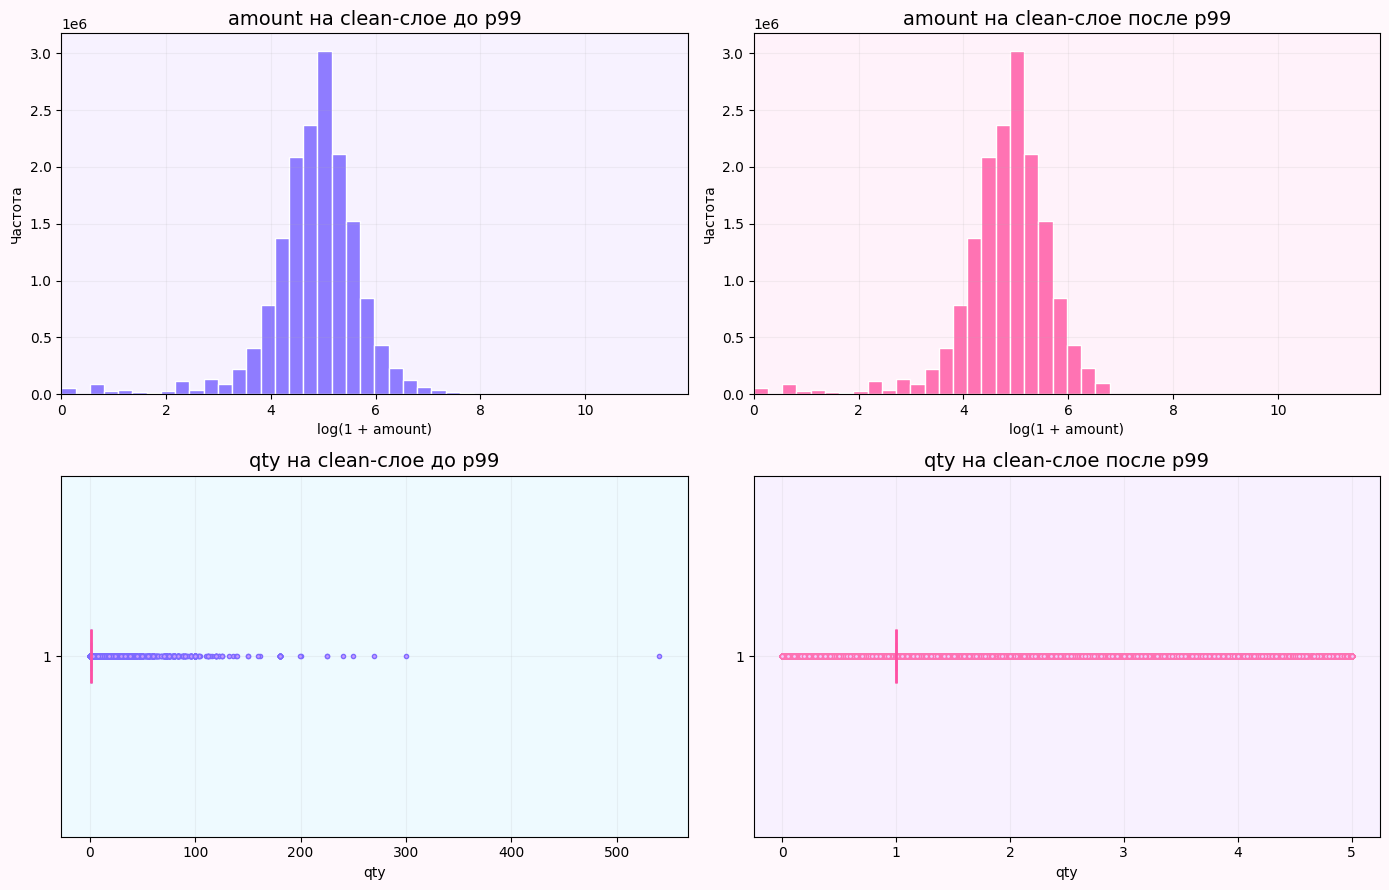

../data/eda_plots/eda_clean_layer_before_after_p99.png


In [55]:
import matplotlib.pyplot as plt
import math
import numpy as np

items_df = lf_items.select(["amount", "qty"]).collect()

amount_data = items_df["amount"].to_list()
qty_data = items_df["qty"].to_list()

amount_p99 = items_df.select(pl.col("amount").quantile(0.99)).item()
qty_p99 = items_df.select(pl.col("qty").quantile(0.99)).item()

amount_trim = [x for x in amount_data if x <= amount_p99]
qty_trim = [x for x in qty_data if x <= qty_p99]

amount_before_log = np.array([math.log1p(x) for x in amount_data])
amount_after_log = np.array([math.log1p(x) for x in amount_trim])

amount_xmax = max(amount_before_log.max(), amount_after_log.max())
amount_bins = np.linspace(0, amount_xmax, 45)

amount_hist_before, _ = np.histogram(amount_before_log, bins=amount_bins)
amount_hist_after, _ = np.histogram(amount_after_log, bins=amount_bins)
amount_ymax = max(amount_hist_before.max(), amount_hist_after.max()) * 1.05

out_dir = Path("../data/eda_plots")
out_dir.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
fig.patch.set_facecolor("#fff8fc")

# amount до
axes[0, 0].hist(amount_before_log, bins=amount_bins, color="#8f7cff", edgecolor="white")
axes[0, 0].set_title("amount на clean-слое до p99", fontsize=14)
axes[0, 0].set_xlabel("log(1 + amount)")
axes[0, 0].set_ylabel("Частота")
axes[0, 0].set_xlim(0, amount_xmax)
axes[0, 0].set_ylim(0, amount_ymax)
axes[0, 0].set_facecolor("#f7f2ff")
axes[0, 0].grid(alpha=0.15)

# amount после
axes[0, 1].hist(amount_after_log, bins=amount_bins, color="#ff73b3", edgecolor="white")
axes[0, 1].set_title("amount на clean-слое после p99", fontsize=14)
axes[0, 1].set_xlabel("log(1 + amount)")
axes[0, 1].set_ylabel("Частота")
axes[0, 1].set_xlim(0, amount_xmax)
axes[0, 1].set_ylim(0, amount_ymax)
axes[0, 1].set_facecolor("#fff2fa")
axes[0, 1].grid(alpha=0.15)

# qty до
axes[1, 0].boxplot(
    qty_data,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#b9e7ff", color="#7d6bff"),
    medianprops=dict(color="#ff4fa3", linewidth=2),
    whiskerprops=dict(color="#7d6bff"),
    capprops=dict(color="#7d6bff"),
    flierprops=dict(marker="o", markerfacecolor="#c89bff", markeredgecolor="#7d6bff", markersize=3),
)
axes[1, 0].set_title("qty на clean-слое до p99", fontsize=14)
axes[1, 0].set_xlabel("qty")
axes[1, 0].set_facecolor("#eefaff")
axes[1, 0].grid(alpha=0.15)

# qty после
axes[1, 1].boxplot(
    qty_trim,
    vert=False,
    patch_artist=True,
    boxprops=dict(facecolor="#ddb8ff", color="#ff73b3"),
    medianprops=dict(color="#ff4fa3", linewidth=2),
    whiskerprops=dict(color="#ff73b3"),
    capprops=dict(color="#ff73b3"),
    flierprops=dict(marker="o", markerfacecolor="#f0cfff", markeredgecolor="#ff73b3", markersize=3),
)
axes[1, 1].set_title("qty на clean-слое после p99", fontsize=14)
axes[1, 1].set_xlabel("qty")
axes[1, 1].set_facecolor("#f8f1ff")
axes[1, 1].grid(alpha=0.15)

plt.tight_layout()

save_path = out_dir / "eda_clean_layer_before_after_p99.png"
plt.savefig(save_path, dpi=220, bbox_inches="tight")
plt.show()

print(save_path)

Нижний хвост распределения в данной работе не отсекается по перцентилям отдельно,так как там большинство - данные содержательные (на развес продукты), а мусорная часть уже обрабатывается очисткой: удаляются строки с `qty <= 0`, `amount < 0`, а специальные случаи вроде бесплатных позиций и микроколичеств фиксируются отдельно. Поэтому дополнительная перцентильная фильтрация применяется только к верхнему хвосту распределения, где экстремальные значения действительно могут смещать средние метрики.

Распределение amount сильно скошено вправо: основная масса строк лежит в компактной центральной области, но есть длинный правый хвост с редкими очень большими значениями. До очистки boxplot сильно растянут именно из-за этого хвоста. После отсечения по 99-му перцентилю центральная часть распределения почти не ломается, зато экстремумы перестают доминировать.

Для qty эффект мягче, но тоже виден: после очистки остаётся компактный диапазон, который лучше отражает типичную покупку.

Из этого следует:
	•	для EDA, описательной аналитики, средних чеков, средних количеств, корзин и сравнений p99-очистка выглядит оправданной;
	•	но для эконометрии исходный слой стоит сохранить, чтобы не зафиксировать за исследователя спорное решение по выбросам.

Таким образом, для выполнени моих заданий ниже самым логичным действием будет применить на витрины очистку из clean_ так же как и перцентили.

Применим на финальных для заданий витринах и перестроем вспомогательные витрины:

In [56]:
import gc

BASE_DIR = Path("..") / "data"
INTERIM_DIR = BASE_DIR / "interim"
MART_DIR = BASE_DIR / "mart"

ITEMS_CLEAN_PATH = INTERIM_DIR / "items_clean.parquet"
PRODUCT_DIM_PATH = MART_DIR / "product_dim.parquet"

LINE_FACT_TASKS_PATH = MART_DIR / "line_fact_tasks.parquet"
CHECK_FACT_TASKS_PATH = MART_DIR / "check_fact_tasks.parquet"
CHECKS_MART_TASKS_PATH = MART_DIR / "checks_mart_tasks.parquet"
USER_MONTH_MART_TASKS_PATH = MART_DIR / "user_month_mart_tasks.parquet"


items_clean = pl.scan_parquet(ITEMS_CLEAN_PATH)

p99 = (
    items_clean
    .select([
        pl.col("amount").quantile(0.99).alias("amount_p99"),
        pl.col("qty").quantile(0.99).alias("qty_p99"),
    ])
    .collect()
)

amount_p99 = float(p99["amount_p99"][0])
qty_p99 = float(p99["qty_p99"][0])

print("amount_p99 =", amount_p99)
print("qty_p99 =", qty_p99)

items_clean_p99 = (
    items_clean
    .filter(pl.col("amount") <= amount_p99)
    .filter(pl.col("qty") <= qty_p99)
)

# -----------------------------
# 2. Обогащение по логике line_fact
# -----------------------------
product_dim = pl.scan_parquet(PRODUCT_DIM_PATH)

product_dim_small = (
    product_dim
    .select([
        pl.col("product_name_raw").alias("product_name"),
        "product_name_clean",
        "is_cream_cheese",
        "cream_cheese_proba",
        "brand",
        "brand_pred",
        "brand_proba",
        "pack_size_g",
        "flavor_group",
        "is_target_violette",
    ])
)

line_fact_tasks = (
    items_clean_p99
    .join(product_dim_small, on="product_name", how="left")
    .with_columns([
        (pl.col("qty") * pl.col("pack_size_g") / 1000).alias("volume_kg"),
        (pl.col("amount") / pl.col("qty")).alias("unit_price"),
        (pl.col("amount") / (pl.col("qty") * pl.col("pack_size_g") / 1000)).alias("price_per_kg"),

        pl.col("ts").dt.day().alias("day"),
        pl.col("ts").dt.weekday().alias("dow"),
        pl.col("ts").dt.hour().alias("hour"),
        pl.col("ts").dt.minute().alias("minute"),
        pl.col("ts").dt.truncate("1w").dt.date().alias("week_start"),
        pl.col("ts").dt.truncate("1mo").dt.date().alias("month_start"),
        (pl.col("ts").dt.weekday() >= 5).alias("is_weekend"),
    ])
)


line_fact_tasks.sink_parquet(str(LINE_FACT_TASKS_PATH))
print("Saved:", LINE_FACT_TASKS_PATH)

del line_fact_tasks
gc.collect()

# -----------------------------
# 3. check_fact_tasks
# Строим уже из сохранённого line_fact_tasks
# -----------------------------
lf_tasks = pl.scan_parquet(LINE_FACT_TASKS_PATH)

check_fact_tasks = (
    lf_tasks
    .group_by("check_id")
    .agg([
        pl.col("buyer_id").first().alias("buyer_id"),
        pl.col("user_synth_id").first().alias("user_synth_id"),
        pl.col("ts").min().alias("ts"),

        pl.col("date").first().alias("date"),
        pl.col("year").first().alias("year"),
        pl.col("month").first().alias("month"),
        pl.col("year_month").first().alias("year_month"),
        pl.col("day").first().alias("day"),
        pl.col("dow").first().alias("dow"),
        pl.col("hour").first().alias("hour"),
        pl.col("minute").first().alias("minute"),
        pl.col("week_start").first().alias("week_start"),
        pl.col("month_start").first().alias("month_start"),
        pl.col("is_weekend").first().alias("is_weekend"),

        pl.col("is_marketplace").first().alias("is_marketplace"),

        pl.col("amount").sum().alias("check_amount"),
        pl.col("qty").sum().alias("check_qty"),
        pl.col("volume_kg").sum().alias("check_volume_kg"),

        pl.col("product_name").n_unique().alias("n_unique_items"),
        pl.col("is_cream_cheese").max().alias("has_cream_cheese"),
        pl.col("is_target_violette").max().alias("has_violette"),
    ])
)

check_fact_tasks.sink_parquet(str(CHECK_FACT_TASKS_PATH))
print("Saved:", CHECK_FACT_TASKS_PATH)

del check_fact_tasks
gc.collect()

# -----------------------------
# 4. checks_mart_tasks
# -----------------------------
cf_tasks = pl.scan_parquet(CHECK_FACT_TASKS_PATH)

checks_mart_tasks = (
    cf_tasks
    .with_columns([
        (pl.col("check_amount") / pl.col("check_qty")).alias("avg_unit_price_in_check"),
        (pl.col("check_amount") / pl.col("check_volume_kg")).alias("avg_price_per_kg_in_check"),
    ])
)

checks_mart_tasks.sink_parquet(str(CHECKS_MART_TASKS_PATH))
print("Saved:", CHECKS_MART_TASKS_PATH)

del checks_mart_tasks
gc.collect()

# -----------------------------
# 5. user_month_mart_tasks
# -----------------------------
lf_tasks = pl.scan_parquet(LINE_FACT_TASKS_PATH)

user_month_mart_tasks = (
    lf_tasks
    .group_by(["buyer_id", "year_month"])
    .agg([
        pl.col("year").first().alias("year"),
        pl.col("month").first().alias("month"),

        pl.col("check_id").n_unique().alias("n_checks"),
        pl.col("amount").sum().alias("total_amount"),
        pl.col("qty").sum().alias("total_qty"),
        pl.col("volume_kg").sum().alias("total_volume_kg"),

        pl.col("is_cream_cheese").sum().alias("n_cream_cheese_rows"),
        pl.col("is_target_violette").sum().alias("n_violette_rows"),

        pl.col("is_marketplace").mean().alias("marketplace_share"),
    ])
)

user_month_mart_tasks.sink_parquet(str(USER_MONTH_MART_TASKS_PATH))
print("Saved:", USER_MONTH_MART_TASKS_PATH)

del user_month_mart_tasks
gc.collect()

amount_p99 = 831.0
qty_p99 = 5.0
Saved: ../data/mart/line_fact_tasks.parquet
Saved: ../data/mart/check_fact_tasks.parquet
Saved: ../data/mart/checks_mart_tasks.parquet
Saved: ../data/mart/user_month_mart_tasks.parquet


0

## Этап 8 - Выполнение заданий

Дальнейший анализ строится на `line_fact_tasks` и производных витринах.  
Для каждого бизнес-вопроса я стараюсь считать не только абсолютные значения, но и более интерпретируемые метрики:

- число покупателей (`n_buyers`);
- число чеков (`n_checks`);
- число строк / позиций (`n_rows`);
- долю внутри релевантной базы (`share`).

Это важно, потому что один и тот же бренд может иметь высокий объём строк, но относительно небольшое число уникальных покупателей, и наоборот.

*Убрала из рейтингов other и no_brand, потому что их отображение собьёт топ, а так в общем надо понимать, что они присутствуют в тех количествах, что были обозначены выше.

In [57]:
import math

BASE_DIR = Path("..") / "data"
MART_DIR = BASE_DIR / "mart"
OUT_DIR = BASE_DIR / "task_outputs"
PLOTS_DIR = OUT_DIR / "plots"
CSV_DIR = OUT_DIR / "csv"

PLOTS_DIR.mkdir(parents=True, exist_ok=True)
CSV_DIR.mkdir(parents=True, exist_ok=True)

LINE_FACT_PATH = MART_DIR / "line_fact_tasks.parquet"
CHECK_FACT_PATH = MART_DIR / "check_fact_tasks.parquet"
CHECKS_MART_PATH = MART_DIR / "checks_mart_tasks.parquet"
USER_MONTH_PATH = MART_DIR / "user_month_mart_tasks.parquet"

lf = pl.read_parquet(LINE_FACT_PATH)
cf = pl.read_parquet(CHECK_FACT_PATH)
cm = pl.read_parquet(CHECKS_MART_PATH)
um = pl.read_parquet(USER_MONTH_PATH)

print(lf.shape, cf.shape, cm.shape, um.shape)

(16057864, 34) (1547975, 22) (1547975, 24) (671349, 11)


### 1 “На кого переключаются наши потребители: покупая творожные сыры Карат Виолетте/Violette, какие еще творожные сыры они покупают, каких брендов? Показать рейтинг переключения.”


In [58]:
EXCLUDE_BRANDS = {"violette", "other", "no_brand", "unknown", None}

violette_buyers = (
    lf
    .filter(pl.col("is_target_violette") == True)
    .select("buyer_id")
    .unique()
)

n_violette_buyers = violette_buyers.height

buyers_other_cc = (
    lf
    .join(violette_buyers, on="buyer_id", how="inner")
    .filter(pl.col("is_cream_cheese") == True)
    .filter(pl.col("brand").is_not_null())
    .filter(~pl.col("brand").str.to_lowercase().is_in(list(EXCLUDE_BRANDS)))
    .filter(pl.col("is_target_violette") == False)
)

switch_rank_1 = (
    buyers_other_cc
    .group_by("brand")
    .agg([
        pl.col("buyer_id").n_unique().alias("n_buyers"),
        pl.col("check_id").n_unique().alias("n_checks"),
        pl.len().alias("n_rows"),
        pl.col("amount").sum().alias("total_amount"),
        pl.col("qty").sum().alias("total_qty"),
    ])
    .with_columns([
        (pl.col("n_buyers") / n_violette_buyers).alias("buyer_share_of_violette_base"),
        pl.lit(n_violette_buyers).alias("violette_buyer_base"),
    ])
    .sort(["n_buyers", "n_checks"], descending=True)
)

switch_rank_1.write_csv(CSV_DIR / "task1_switch_rank_overall.csv")
switch_rank_1.head(20)

brand,n_buyers,n_checks,n_rows,total_amount,total_qty,buyer_share_of_violette_base,violette_buyer_base
str,u32,u32,u32,f64,f64,f64,i32
"""hochland""",3999,33162,34715,7.1775e6,39720.65,0.823178,4858
"""almette""",3050,22413,23599,3700339.2,26375.0,0.62783,4858
"""president""",2467,10710,11082,1.4013e6,12376.552,0.507822,4858
"""ekomilk""",2362,18619,18637,5.2199e6,24054.75,0.486208,4858
"""sveza""",2359,16299,17189,1.9670e6,19715.0,0.485591,4858
"""viola""",1452,3923,4107,488791.69,4667.0,0.298888,4858
"""savushkin""",848,3332,3372,363818.82,3900.0,0.174557,4858
"""schonfeld""",609,1249,1257,152462.0,1346.0,0.12536,4858
"""pretto""",490,1128,1190,160675.43,1331.0,0.100865,4858


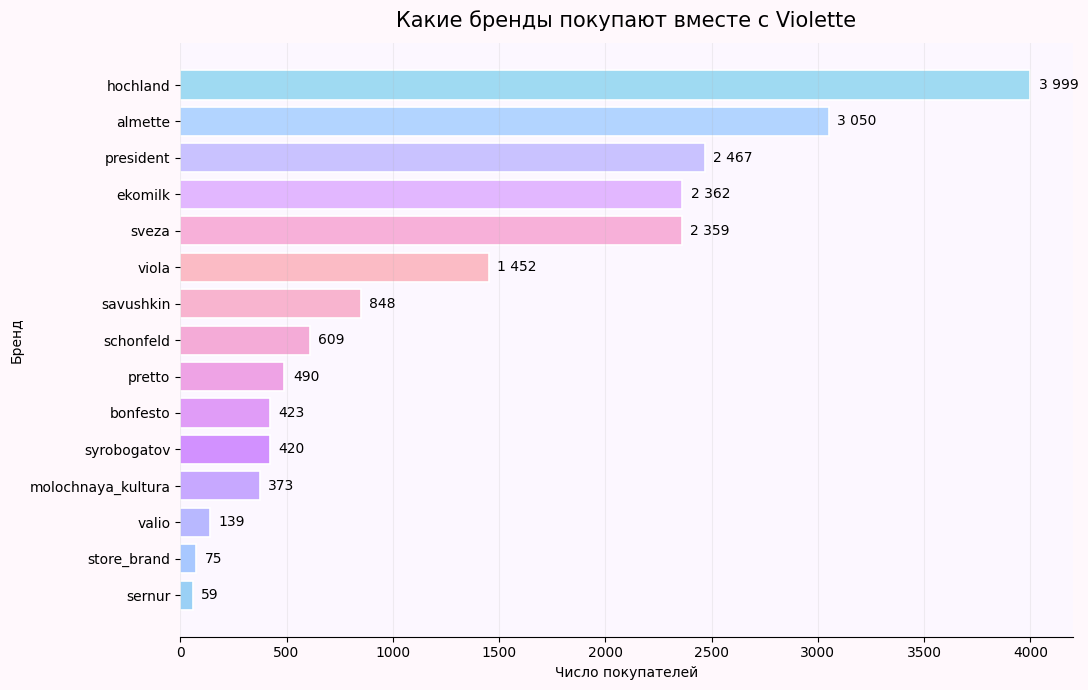

In [59]:
top1 = switch_rank_1.head(15).to_pandas()

# разворачиваем, чтобы самый большой был сверху
brands = top1["brand"][::-1]
values = top1["n_buyers"][::-1]

palette = [
    "#9ad0f5", "#a8c8ff", "#b8b8ff", "#c7a8ff", "#d291ff",
    "#e09cf7", "#eea3e5", "#f4abd7", "#f8b4cf", "#fbbbc5",
    "#f7b0d9", "#e2b7ff", "#c9c2ff", "#b2d4ff", "#9fdaf2"
]

colors = palette[:len(brands)]
if len(brands) > len(colors):
    colors = (palette * (len(brands) // len(palette) + 1))[:len(brands)]

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("#fff8fc")
ax.set_facecolor("#fcf7ff")

bars = ax.barh(brands, values, color=colors, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_width() + max(values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(val):,}".replace(",", " "),
        va="center",
        fontsize=10
    )

ax.set_title("Какие бренды покупают вместе с Violette", fontsize=15, pad=12)
ax.set_xlabel("Число покупателей")
ax.set_ylabel("Бренд")

ax.grid(axis="x", alpha=0.18)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "task1_switch_rank_overall_pretty.png", dpi=220, bbox_inches="tight")
plt.show()

Для задания 1 базой сравнения является число уникальных покупателей, которые хотя бы раз покупали Violette (`violette_buyer_base`). Рейтинг строится по числу таких покупателей, у которых встречались и другие бренды творожных сыров. Дополнительно считаются число чеков, суммарная выручка и суммарное количество, чтобы различать широкое покупательское пересечение и просто частое появление бренда в транзакциях.

### 2 “Те, кто покупал творожные сыры Violette в прошлом году, но не покупает в этом году: на какие бренды творожных сыров он переключился (рейтинг).”


In [60]:
lf_year = lf.with_columns(pl.col("ts").dt.year().alias("year"))

YEAR_PREV = 2024
YEAR_CURR = 2025

buyers_v_prev = (
    lf_year
    .filter((pl.col("year") == YEAR_PREV) & (pl.col("is_target_violette") == True))
    .select("buyer_id")
    .unique()
)

buyers_v_curr = (
    lf_year
    .filter((pl.col("year") == YEAR_CURR) & (pl.col("is_target_violette") == True))
    .select("buyer_id")
    .unique()
)

churn_buyers = buyers_v_prev.join(buyers_v_curr, on="buyer_id", how="anti")
n_churn_buyers = churn_buyers.height

switch_rank_2 = (
    lf_year
    .join(churn_buyers, on="buyer_id", how="inner")
    .filter((pl.col("year") == YEAR_CURR) & (pl.col("is_cream_cheese") == True))
    .filter(pl.col("brand").is_not_null())
    .filter(~pl.col("brand").str.to_lowercase().is_in(list(EXCLUDE_BRANDS)))
    .filter(pl.col("is_target_violette") == False)
    .group_by("brand")
    .agg([
        pl.col("buyer_id").n_unique().alias("n_buyers"),
        pl.col("check_id").n_unique().alias("n_checks"),
        pl.col("amount").sum().alias("total_amount"),
        pl.col("qty").sum().alias("total_qty"),
    ])
    .with_columns([
        (pl.col("n_buyers") / n_churn_buyers).alias("buyer_share_of_churn_base"),
        pl.lit(n_churn_buyers).alias("churn_buyer_base"),
    ])
    .sort(["n_buyers", "n_checks"], descending=True)
)

switch_rank_2.write_csv(CSV_DIR / "task2_churn_switch_rank.csv")
switch_rank_2.head(20)

brand,n_buyers,n_checks,total_amount,total_qty,buyer_share_of_churn_base,churn_buyer_base
str,u32,u32,f64,f64,f64,i32
"""hochland""",368,1670,335227.66,1843.0,0.426914,862
"""sveza""",305,1713,211322.53,2054.0,0.353828,862
"""almette""",280,1122,192578.31,1240.0,0.324826,862
"""president""",220,707,100206.98,799.0,0.25522,862
"""ekomilk""",205,833,204870.34,953.0,0.237819,862
"""savushkin""",89,298,29909.6,323.0,0.103248,862
"""molochnaya_kultura""",78,249,27927.38,272.0,0.090487,862
"""viola""",65,110,16122.87,124.0,0.075406,862
"""pretto""",58,98,12889.44,108.0,0.067285,862


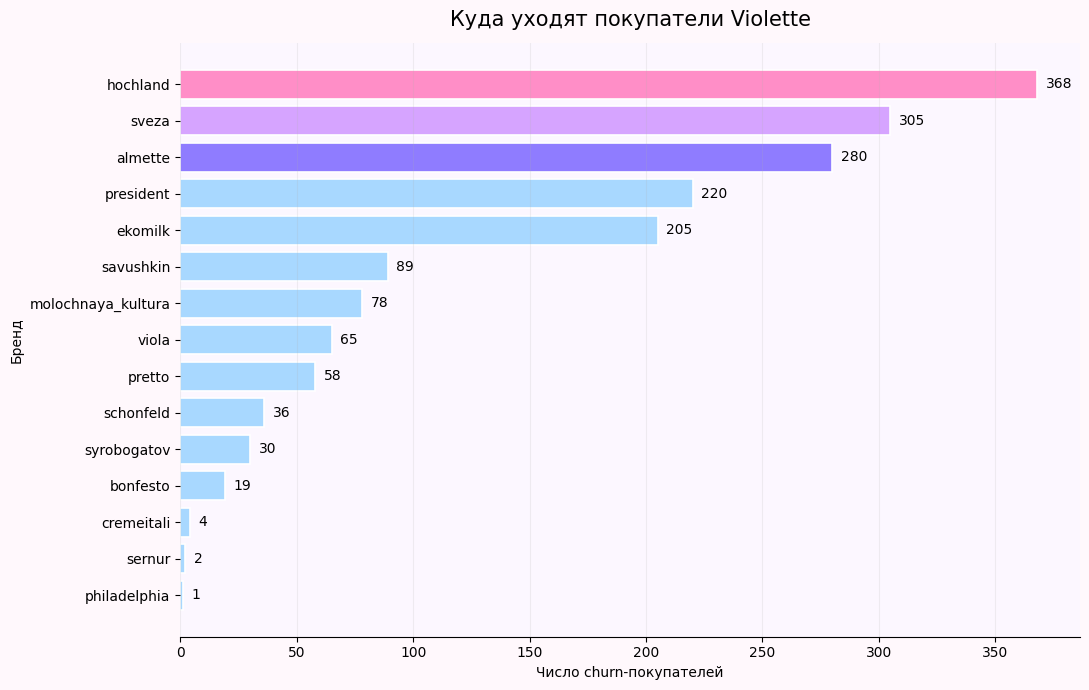

In [61]:
top2 = switch_rank_2.head(15).to_pandas()

brands = top2["brand"][::-1]
values = top2["n_buyers"][::-1]

n = len(brands)
colors = ["#a8d8ff"] * n

if n >= 1:
    colors[-1] = "#ff8ec7"
if n >= 2:
    colors[-2] = "#d6a4ff" 
if n >= 3:
    colors[-3] = "#8f7cff"

fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor("#fff8fc")
ax.set_facecolor("#fcf7ff")

bars = ax.barh(brands, values, color=colors, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_width() + max(values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(val):,}".replace(",", " "),
        va="center",
        fontsize=10
    )

ax.set_title("Куда уходят покупатели Violette", fontsize=15, pad=12)
ax.set_xlabel("Число churn-покупателей")
ax.set_ylabel("Бренд")
ax.grid(axis="x", alpha=0.18)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "task2_churn_switch_rank_pretty.png", dpi=220, bbox_inches="tight")
plt.show()

Для задания 2 базой сравнения является число покупателей, которые покупали Violette в предыдущем году, но не покупали его в текущем (`churn_buyer_base`). Рейтинг показывает не просто конкурентное пересечение, а именно направление возможного оттока.

### 3 “Какие продукты чаще всего попадают в чек вместе с творожными сырами.”


In [62]:
cream_checks = (
    lf
    .filter(pl.col("is_cream_cheese") == True)
    .select(["check_id"])
    .unique()
)

n_cream_checks = cream_checks.height

basket_with_cream = (
    lf
    .join(cream_checks, on="check_id", how="inner")
    .filter(pl.col("is_cream_cheese") == False)
)

copurchase_products_3 = (
    basket_with_cream
    .group_by("product_name_clean")
    .agg([
        pl.col("check_id").n_unique().alias("n_checks"),
        pl.col("buyer_id").n_unique().alias("n_buyers"),
        pl.col("amount").sum().alias("total_amount"),
    ])
    .with_columns([
        (pl.col("n_checks") / n_cream_checks).alias("check_share_of_cream_base"),
        pl.lit(n_cream_checks).alias("cream_check_base"),
    ])
    .sort("n_checks", descending=True)
)

copurchase_brands_3 = (
    basket_with_cream
    .filter(pl.col("brand").is_not_null())
    .group_by("brand")
    .agg([
        pl.col("check_id").n_unique().alias("n_checks"),
        pl.col("buyer_id").n_unique().alias("n_buyers"),
        pl.col("amount").sum().alias("total_amount"),
    ])
    .with_columns([
        (pl.col("n_checks") / n_cream_checks).alias("check_share_of_cream_base"),
        pl.lit(n_cream_checks).alias("cream_check_base"),
    ])
    .sort("n_checks", descending=True)
)

copurchase_products_3.write_csv(CSV_DIR / "task3_copurchase_products.csv")
copurchase_brands_3.write_csv(CSV_DIR / "task3_copurchase_brands.csv")

copurchase_products_3.head(20), copurchase_brands_3.head(20)

(shape: (20, 6)
 ┌─────────────────────┬──────────┬──────────┬──────────────┬────────────────────┬──────────────────┐
 │ product_name_clean  ┆ n_checks ┆ n_buyers ┆ total_amount ┆ check_share_of_cre ┆ cream_check_base │
 │ ---                 ┆ ---      ┆ ---      ┆ ---          ┆ am_base            ┆ ---              │
 │ str                 ┆ u32      ┆ u32      ┆ f64          ┆ ---                ┆ i32              │
 │                     ┆          ┆          ┆              ┆ f64                ┆                  │
 ╞═════════════════════╪══════════╪══════════╪══════════════╪════════════════════╪══════════════════╡
 │ Доставка            ┆ 166760   ┆ 13462    ┆ 2.6788e7     ┆ 0.162499           ┆ 1026222          │
 │ Пакет-майка         ┆ 76163    ┆ 10229    ┆ 1.2911e6     ┆ 0.074217           ┆ 1026222          │
 │ 35+18х61            ┆          ┆          ┆              ┆                    ┆                  │
 │ Пакет-майка         ┆ 69672    ┆ 10525    ┆ 1.2878e6     ┆ 0.06

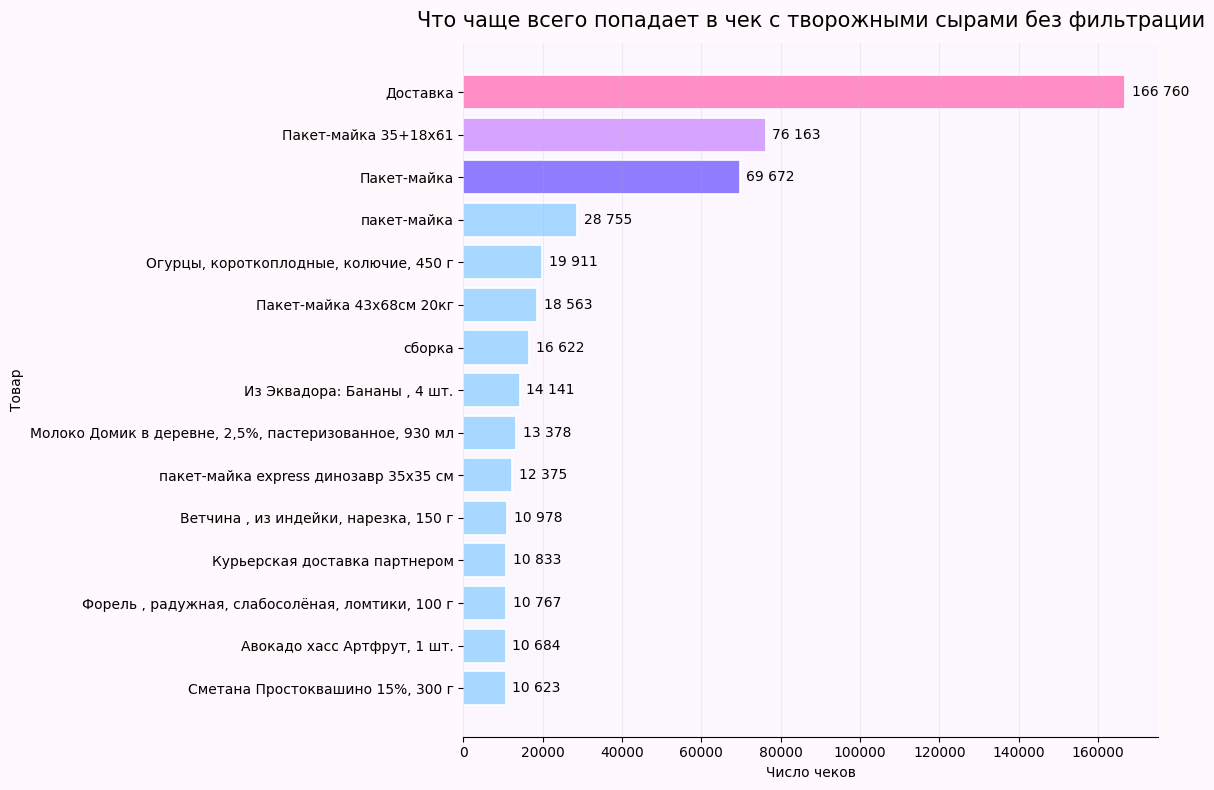

In [63]:
top3 = copurchase_products_3.head(15).to_pandas()

products = top3["product_name_clean"][::-1]
values = top3["n_checks"][::-1]

colors = ["#a8d8ff"] * len(products)
if len(products) >= 1:
    colors[-1] = "#ff8ec7"
if len(products) >= 2:
    colors[-2] = "#d6a4ff"
if len(products) >= 3:
    colors[-3] = "#8f7cff"

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("#fff8fc")
ax.set_facecolor("#fcf7ff")

bars = ax.barh(products, values, color=colors, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_width() + max(values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(val):,}".replace(",", " "),
        va="center",
        fontsize=10
    )

ax.set_title("Что чаще всего попадает в чек с творожными сырами без фильтрации", fontsize=15, pad=12)
ax.set_xlabel("Число чеков")
ax.set_ylabel("Товар")
ax.grid(axis="x", alpha=0.18)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "task3_copurchase_products_with_other_things_pretty.png", dpi=220, bbox_inches="tight")
plt.show()

Для задания 3 базой сравнения является число чеков, в которых присутствовал хотя бы один творожный сыр (`cream_check_base`). Это позволяет интерпретировать не только абсолютные значения, но и долю чеков категории, в которых встречается сопутствующий товар.

Видим, что у нас есть включения ненужного, так что проведём очистку.

In [64]:
service_masks = [
    "доставка",
    "курьер",
    "сборка",
    "пакет",
    "пакет-майка",
    "express",
]

copurchase_products_3_real = (
    basket_with_cream
    .filter(pl.col("product_name_clean").is_not_null())
    .filter(
        ~pl.col("product_name_clean")
        .str.to_lowercase()
        .str.contains("|".join(service_masks))
    )
    .group_by("product_name_clean")
    .agg([
        pl.col("check_id").n_unique().alias("n_checks"),
        pl.col("buyer_id").n_unique().alias("n_buyers"),
        pl.col("amount").sum().alias("total_amount"),
    ])
    .with_columns([
        (pl.col("n_checks") / n_cream_checks).alias("check_share_of_cream_base"),
        pl.lit(n_cream_checks).alias("cream_check_base"),
    ])
    .sort("n_checks", descending=True)
)

copurchase_products_3_real.write_csv(CSV_DIR / "task3_copurchase_products_real_only.csv")

copurchase_products_3_real.head(20)

product_name_clean,n_checks,n_buyers,total_amount,check_share_of_cream_base,cream_check_base
str,u32,u32,f64,f64,i32
"""Огурцы, короткоплодные, колючие, 450 г""",19911,8634,2.9858e6,0.019402,1026222
"""Из Эквадора: Бананы , 4 шт.""",14141,6218,2.1771e6,0.01378,1026222
"""Молоко Домик в деревне, 2,5%, пастеризованное, 930 мл""",13378,5874,1.2825e6,0.013036,1026222
"""Ветчина , из индейки, нарезка, 150 г""",10978,4326,2.1117e6,0.010697,1026222
"""Форель , радужная, слабосолёная, ломтики, 100 г""",10767,5514,3.2501e6,0.010492,1026222
"""Авокадо хасс Артфрут, 1 шт.""",10684,5197,1859458.7,0.010411,1026222
"""Сметана Простоквашино 15%, 300 г""",10623,5474,1058692.8,0.010352,1026222
"""Батон Нарезной 400 г, Коломенский, в нарезке""",10455,3410,671911.55,0.010188,1026222
"""Молоко Простоквашино, 2,5%, пастеризованное, 930 мл""",9282,4556,865075.93,0.009045,1026222


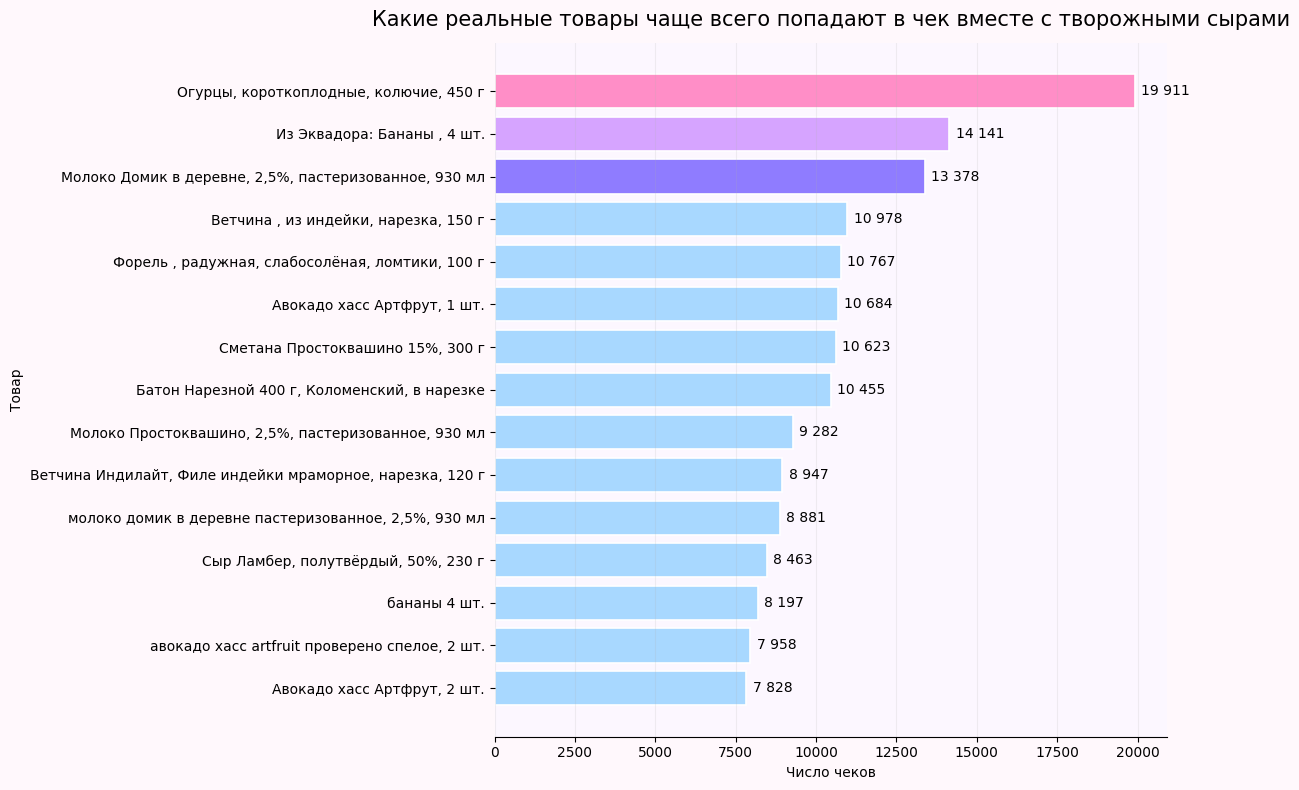

In [65]:
top3_real = copurchase_products_3_real.head(15).to_pandas()

products = top3_real["product_name_clean"][::-1]
values = top3_real["n_checks"][::-1]

n = len(products)
colors = ["#a8d8ff"] * n

if n >= 1:
    colors[-1] = "#ff8ec7"
if n >= 2:
    colors[-2] = "#d6a4ff"
if n >= 3:
    colors[-3] = "#8f7cff"

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("#fff8fc")
ax.set_facecolor("#fcf7ff")

bars = ax.barh(products, values, color=colors, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_width() + max(values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(val):,}".replace(",", " "),
        va="center",
        fontsize=10
    )

ax.set_title("Какие реальные товары чаще всего попадают в чек вместе с творожными сырами", fontsize=15, pad=12)
ax.set_xlabel("Число чеков")
ax.set_ylabel("Товар")
ax.grid(axis="x", alpha=0.18)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "task3_copurchase_products_real_only.png", dpi=220, bbox_inches="tight")
plt.show()

Убрала вспомогательное, теперь предлагаю объединить одни продукты с разным происхождением и заново посмотреть.

In [66]:
copurchase_products_3_grouped = (
    basket_with_cream
    .filter(pl.col("product_name_clean").is_not_null())
    .filter(
        ~pl.col("product_name_clean")
        .str.to_lowercase()
        .str.contains("|".join(service_masks))
    )
    .with_columns(
        pl.col("product_name_clean")
        .str.to_lowercase()
        .str.replace_all(r"[,:;.!()]+", " ")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
        .alias("product_name_norm")
    )
    .with_columns(
        pl.when(pl.col("product_name_norm").str.contains("сметан"))
        .then(pl.lit("Сметана"))

        .when(pl.col("product_name_norm").str.contains("молоко"))
        .then(pl.lit("Молоко"))

        .when(pl.col("product_name_norm").str.contains("яйц"))
        .then(pl.lit("Яйца"))

        .when(pl.col("product_name_norm").str.contains("банан"))
        .then(pl.lit("Бананы"))

        .when(
            pl.col("product_name_norm").str.contains("авокадо")
            & pl.col("product_name_norm").str.contains("хасс")
        )
        .then(pl.lit("Авокадо хасс"))

        .when(pl.col("product_name_norm").str.contains("огур"))
        .then(pl.lit("Огурцы"))

        .when(pl.col("product_name_norm").str.contains("томат") | pl.col("product_name_norm").str.contains("помид"))
        .then(pl.lit("Томаты"))

        .when(
            pl.col("product_name_norm").str.contains("ветчина")
            & pl.col("product_name_norm").str.contains("индейк")
        )
        .then(pl.lit("Ветчина из индейки"))

        .when(pl.col("product_name_norm").str.contains("форел"))
        .then(pl.lit("Форель"))

        .when(pl.col("product_name_norm").str.contains("батон"))
        .then(pl.lit("Батон"))

        .when(pl.col("product_name_norm").str.contains("круассан"))
        .then(pl.lit("Круассан"))

        .when(pl.col("product_name_norm").str.contains("сыр ламбер"))
        .then(pl.lit("Сыр Ламбер"))

        .when(pl.col("product_name_norm").str.contains("салат айсберг"))
        .then(pl.lit("Салат Айсберг"))

        .otherwise(pl.col("product_name_clean"))
        .alias("product_name_group")
    )
    .group_by("product_name_group")
    .agg([
        pl.col("check_id").n_unique().alias("n_checks"),
        pl.col("buyer_id").n_unique().alias("n_buyers"),
        pl.col("amount").sum().alias("total_amount"),
    ])
    .with_columns([
        (pl.col("n_checks") / n_cream_checks).alias("check_share_of_cream_base"),
        pl.lit(n_cream_checks).alias("cream_check_base"),
    ])
    .sort("n_checks", descending=True)
)

copurchase_products_3_grouped.write_csv(CSV_DIR / "task3_copurchase_products_grouped.csv")
copurchase_products_3_grouped.head(20)

product_name_group,n_checks,n_buyers,total_amount,check_share_of_cream_base,cream_check_base
str,u32,u32,f64,f64,i32
"""Огурцы""",287839,31882,5.2153e7,0.280484,1026222
"""Молоко""",280346,31429,4.0469e7,0.273183,1026222
"""Томаты""",251814,31378,5.7747e7,0.24538,1026222
"""Яйца""",231298,30663,3.4893e7,0.225388,1026222
"""Сметана""",172235,28865,1.9733e7,0.167834,1026222
"""Батон""",151427,27648,1.7031e7,0.147558,1026222
"""Бананы""",150352,26533,2.3652e7,0.14651,1026222
"""Форель""",88763,21046,3.1580e7,0.086495,1026222
"""Авокадо хасс""",71442,16294,1.7160e7,0.069617,1026222


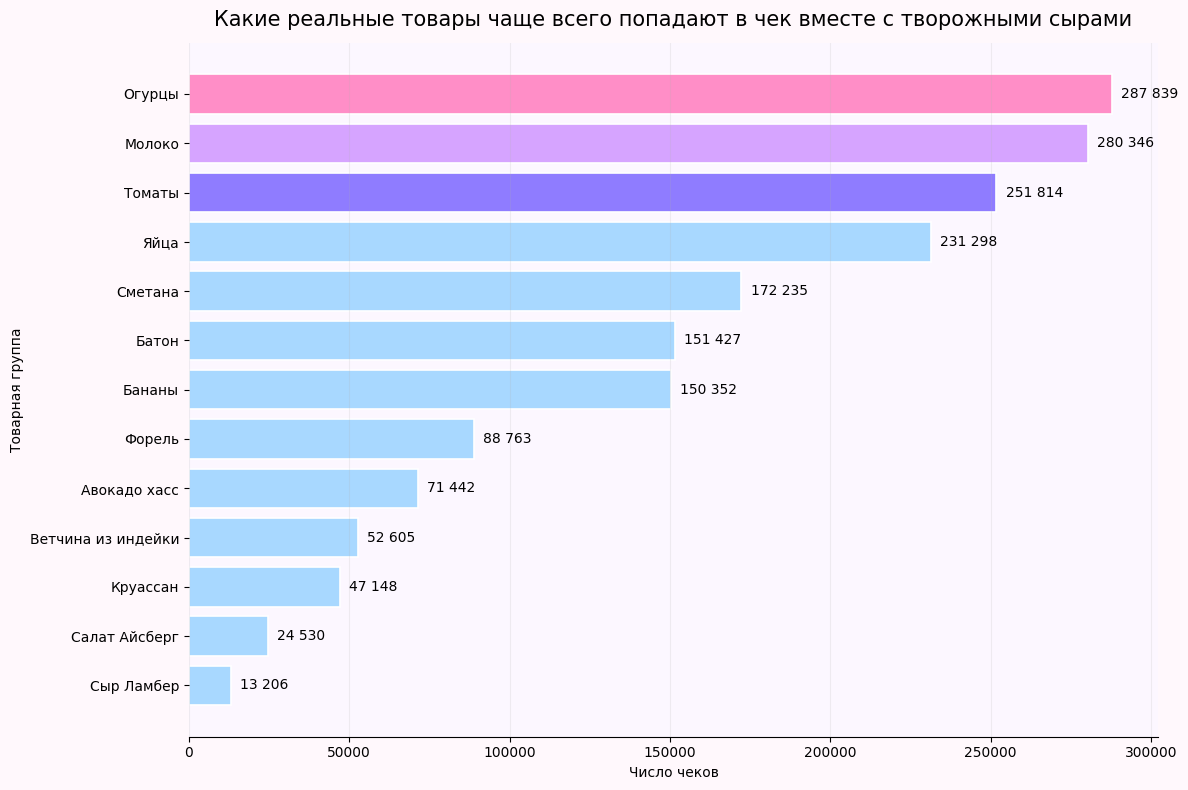

In [67]:
top3_grouped = copurchase_products_3_grouped.head(13).to_pandas()

products = top3_grouped["product_name_group"][::-1]
values = top3_grouped["n_checks"][::-1]

colors = ["#a8d8ff"] * len(products)
if len(products) >= 1:
    colors[-1] = "#ff8ec7"
if len(products) >= 2:
    colors[-2] = "#d6a4ff"
if len(products) >= 3:
    colors[-3] = "#8f7cff"

fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor("#fff8fc")
ax.set_facecolor("#fcf7ff")

bars = ax.barh(products, values, color=colors, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_width() + max(values) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{int(val):,}".replace(",", " "),
        va="center",
        fontsize=10
    )

ax.set_title("Какие реальные товары чаще всего попадают в чек вместе с творожными сырами", fontsize=15, pad=12)
ax.set_xlabel("Число чеков")
ax.set_ylabel("Товарная группа")
ax.grid(axis="x", alpha=0.18)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "task3_copurchase_products_grouped.png", dpi=220, bbox_inches="tight")
plt.show()

### 4 “С какой регулярностью покупают творожные сыры Violette.”


In [68]:
violette_checks = (
    lf
    .filter(pl.col("is_target_violette") == True)
    .select(["buyer_id", "check_id", "ts"])
    .unique()
    .sort(["buyer_id", "ts"])
)

violette_gaps = (
    violette_checks
    .with_columns(pl.col("ts").shift(1).over("buyer_id").alias("prev_ts"))
    .with_columns((pl.col("ts") - pl.col("prev_ts")).dt.total_days().alias("gap_days"))
    .filter(pl.col("prev_ts").is_not_null())
)

buyer_regularity_4 = (
    violette_gaps
    .group_by("buyer_id")
    .agg([
        pl.col("gap_days").median().alias("median_gap_days"),
        pl.col("gap_days").mean().alias("mean_gap_days"),
        pl.len().alias("n_gaps"),
    ])
    .with_columns(
        pl.when(pl.col("median_gap_days") <= 14).then(pl.lit("high_freq"))
        .when(pl.col("median_gap_days") <= 30).then(pl.lit("monthly_like"))
        .when(pl.col("median_gap_days") <= 60).then(pl.lit("low_freq"))
        .otherwise(pl.lit("rare"))
        .alias("frequency_segment")
    )
)

reg_summary_4 = (
    buyer_regularity_4
    .select([
        pl.len().alias("n_buyers_with_2plus_violette_checks"),
        pl.col("median_gap_days").median().alias("median_of_median_gap_days"),
        pl.col("median_gap_days").quantile(0.25).alias("q25_median_gap_days"),
        pl.col("median_gap_days").quantile(0.75).alias("q75_median_gap_days"),
    ])
)

reg_segments_4 = (
    buyer_regularity_4
    .group_by("frequency_segment")
    .agg(pl.len().alias("n_buyers"))
    .sort("n_buyers", descending=True)
)

buyer_regularity_4.write_csv(CSV_DIR / "task4_buyer_regularity.csv")
reg_segments_4.write_csv(CSV_DIR / "task4_regularity_segments.csv")

reg_summary_4, reg_segments_4

(shape: (1, 4)
 ┌───────────────────────────┬──────────────────────────┬─────────────────────┬─────────────────────┐
 │ n_buyers_with_2plus_viole ┆ median_of_median_gap_day ┆ q25_median_gap_days ┆ q75_median_gap_days │
 │ tte_checks                ┆ s                        ┆ ---                 ┆ ---                 │
 │ ---                       ┆ ---                      ┆ f64                 ┆ f64                 │
 │ u32                       ┆ f64                      ┆                     ┆                     │
 ╞═══════════════════════════╪══════════════════════════╪═════════════════════╪═════════════════════╡
 │ 3049                      ┆ 23.5                     ┆ 9.0                 ┆ 65.5                │
 └───────────────────────────┴──────────────────────────┴─────────────────────┴─────────────────────┘,
 shape: (4, 2)
 ┌───────────────────┬──────────┐
 │ frequency_segment ┆ n_buyers │
 │ ---               ┆ ---      │
 │ str               ┆ u32      │
 ╞═══════════════

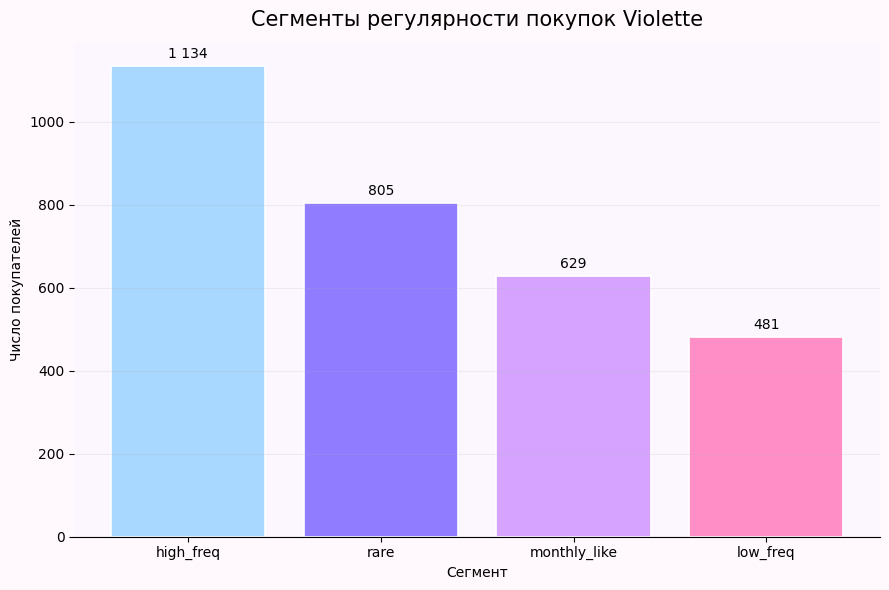

In [69]:
seg4 = reg_segments_4.to_pandas()

segments = seg4["frequency_segment"]
values = seg4["n_buyers"]

colors = ["#a8d8ff", "#8f7cff", "#d6a4ff", "#ff8ec7"][:len(segments)]

fig, ax = plt.subplots(figsize=(9, 6))
fig.patch.set_facecolor("#fff8fc")
ax.set_facecolor("#fcf7ff")

bars = ax.bar(segments, values, color=colors, edgecolor="white", linewidth=1.2)

for bar, val in zip(bars, values):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(values) * 0.01,
        f"{int(val):,}".replace(",", " "),
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("Сегменты регулярности покупок Violette", fontsize=15, pad=12)
ax.set_xlabel("Сегмент")
ax.set_ylabel("Число покупателей")
ax.grid(axis="y", alpha=0.18)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "task4_regularity_segments_pretty.png", dpi=220, bbox_inches="tight")
plt.show()

	•	high_freq → Частые
	•	monthly_like → Около месяца
	•	low_freq → Редкие
	•	rare → Очень редкие

Для задания 4 базой сравнения являются только те покупатели, у которых было минимум две покупки Violette, так как только для них можно посчитать интервал между покупками. Основная метрика — медианный интервал между соседними покупками.

### "5 Разбивки по маркетплейсам / ассортименту / месяцам"


5.1 Переключение брендов: по маркетплейсам

In [70]:
switch_rank_1_marketplace = (
    buyers_other_cc
    .group_by(["is_marketplace", "brand"])
    .agg(pl.col("buyer_id").n_unique().alias("n_buyers"))
    .sort(["is_marketplace", "n_buyers"], descending=[False, True])
)

switch_rank_1_marketplace.write_csv(CSV_DIR / "task5_switch_rank_by_marketplace.csv")
switch_rank_1_marketplace.head(20)

is_marketplace,brand,n_buyers
bool,str,u32
false,"""hochland""",3061
false,"""almette""",2368
false,"""president""",1872
false,"""ekomilk""",1368
false,"""sveza""",1356
false,"""viola""",938
false,"""savushkin""",791
false,"""schonfeld""",581
false,"""pretto""",414


5.2 Переключение брендов: по месяцам

In [71]:
switch_rank_1_month = (
    buyers_other_cc
    .group_by(["year_month", "brand"])
    .agg(pl.col("buyer_id").n_unique().alias("n_buyers"))
    .sort(["year_month", "n_buyers"], descending=[False, True])
)

switch_rank_1_month.write_csv(CSV_DIR / "task5_switch_rank_by_month.csv")
switch_rank_1_month.head(20)

year_month,brand,n_buyers
str,str,u32
"""2023-01""","""hochland""",691
"""2023-01""","""almette""",279
"""2023-01""","""viola""",176
"""2023-01""","""president""",171
"""2023-01""","""ekomilk""",91
"""2023-01""","""savushkin""",49
"""2023-01""","""sveza""",43
"""2023-01""","""syrobogatov""",36
"""2023-01""","""bonfesto""",33


5.3 Переключение брендов: по вкусу и упаковке

In [72]:
switch_rank_1_flavor = (
    buyers_other_cc
    .group_by(["flavor_group", "brand"])
    .agg(pl.col("buyer_id").n_unique().alias("n_buyers"))
    .sort(["flavor_group", "n_buyers"], descending=[False, True])
)

switch_rank_1_pack = (
    buyers_other_cc
    .with_columns(
        pl.when(pl.col("pack_size_g").is_null()).then(pl.lit("unknown"))
        .when(pl.col("pack_size_g") < 140).then(pl.lit("small"))
        .when(pl.col("pack_size_g") <= 220).then(pl.lit("medium"))
        .otherwise(pl.lit("large"))
        .alias("pack_bucket")
    )
    .group_by(["pack_bucket", "brand"])
    .agg(pl.col("buyer_id").n_unique().alias("n_buyers"))
    .sort(["pack_bucket", "n_buyers"], descending=[False, True])
)

switch_rank_1_flavor.write_csv(CSV_DIR / "task5_switch_rank_by_flavor.csv")
switch_rank_1_pack.write_csv(CSV_DIR / "task5_switch_rank_by_pack.csv")

5.4 Co-purchase по маркетплейсам

In [73]:
copurchase_products_5_marketplace = (
    basket_with_cream
    .group_by(["is_marketplace", "product_name_clean"])
    .agg(pl.col("check_id").n_unique().alias("n_checks"))
    .sort(["is_marketplace", "n_checks"], descending=[False, True])
)

copurchase_products_5_marketplace.write_csv(CSV_DIR / "task5_copurchase_by_marketplace.csv")
copurchase_products_5_marketplace.head(20)

is_marketplace,product_name_clean,n_checks
bool,str,u32
false,"""Огурцы, короткоплодные, колючие, 450 г""",19911
false,"""Пакет-майка 43х68см 20кг""",18563
false,"""Из Эквадора: Бананы , 4 шт.""",14141
false,"""Молоко Домик в деревне, 2,5%, пастеризованное, 930 мл""",13378
false,"""Ветчина , из индейки, нарезка, 150 г""",10978
false,"""Форель , радужная, слабосолёная, ломтики, 100 г""",10767
false,"""Авокадо хасс Артфрут, 1 шт.""",10684
false,"""Молоко Простоквашино, 2,5%, пастеризованное, 930 мл""",9282
false,"""Ветчина Индилайт, Филе индейки мраморное, нарезка, 120 г""",8944


5.5 Регулярность по маркетплейсам

In [74]:
violette_checks_mp = (
    lf
    .filter(pl.col("is_target_violette") == True)
    .select(["buyer_id", "check_id", "ts", "is_marketplace"])
    .unique()
    .sort(["buyer_id", "ts"])
)

violette_gaps_mp = (
    violette_checks_mp
    .with_columns(pl.col("ts").shift(1).over("buyer_id").alias("prev_ts"))
    .with_columns((pl.col("ts") - pl.col("prev_ts")).dt.total_days().alias("gap_days"))
    .filter(pl.col("prev_ts").is_not_null())
)

reg_by_marketplace_5 = (
    violette_gaps_mp
    .group_by("is_marketplace")
    .agg([
        pl.col("gap_days").median().alias("median_gap_days"),
        pl.col("gap_days").mean().alias("mean_gap_days"),
        pl.len().alias("n_gaps"),
    ])
)

reg_by_marketplace_5.write_csv(CSV_DIR / "task5_regularity_by_marketplace.csv")
reg_by_marketplace_5

is_marketplace,median_gap_days,mean_gap_days,n_gaps
bool,f64,f64,u32
false,14.0,50.853446,9082
true,9.0,54.924293,8414


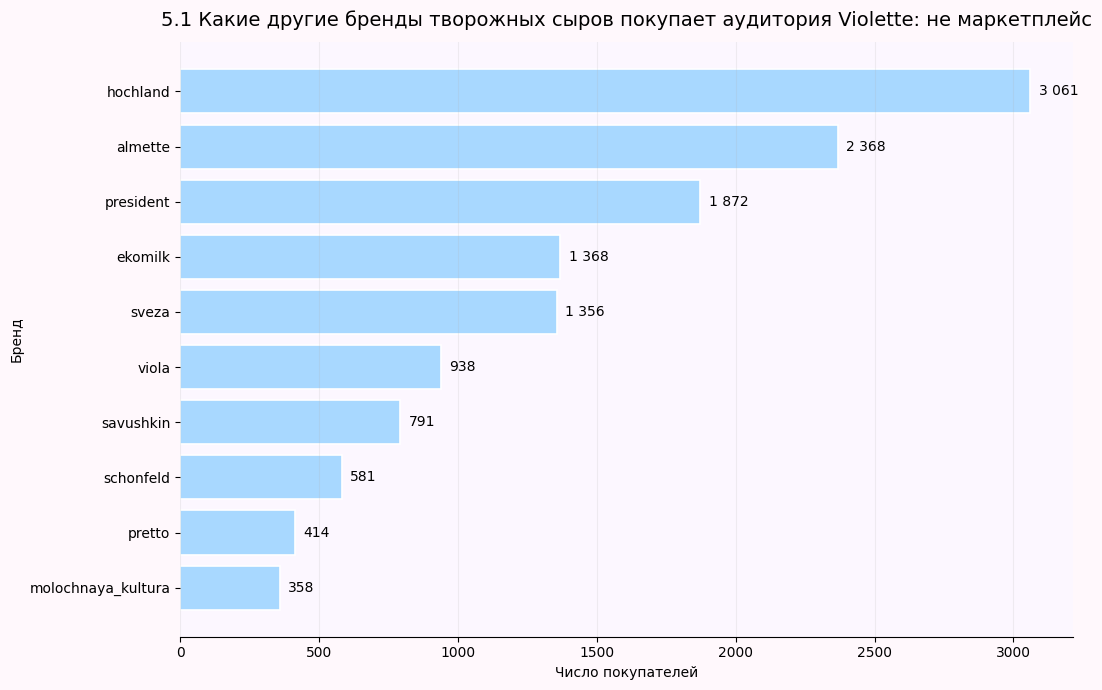

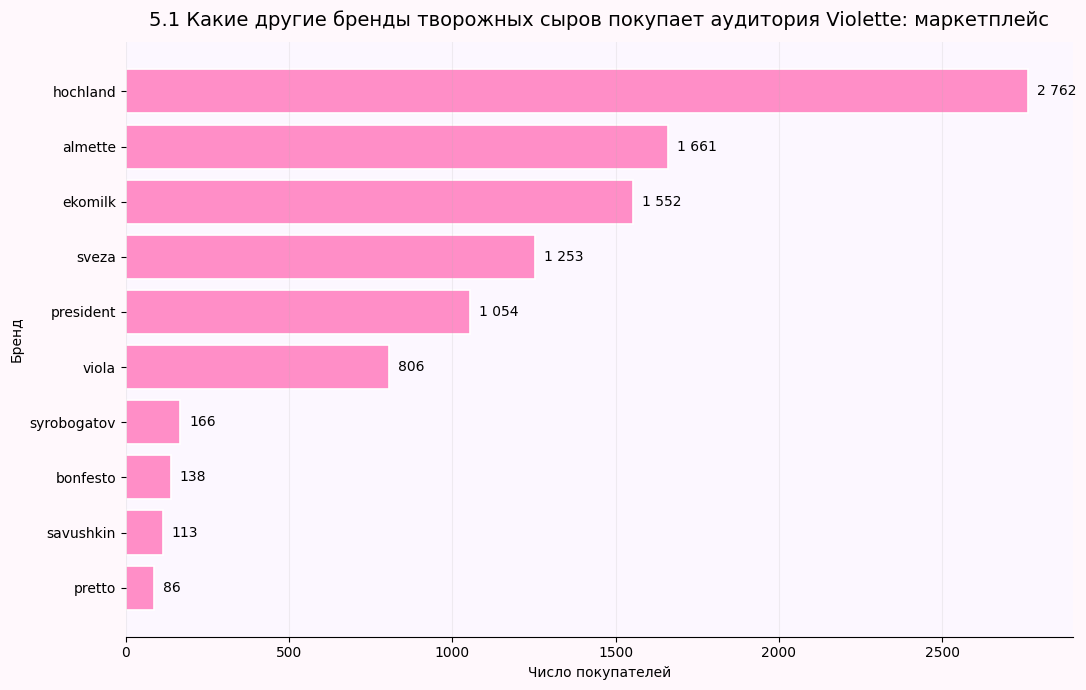

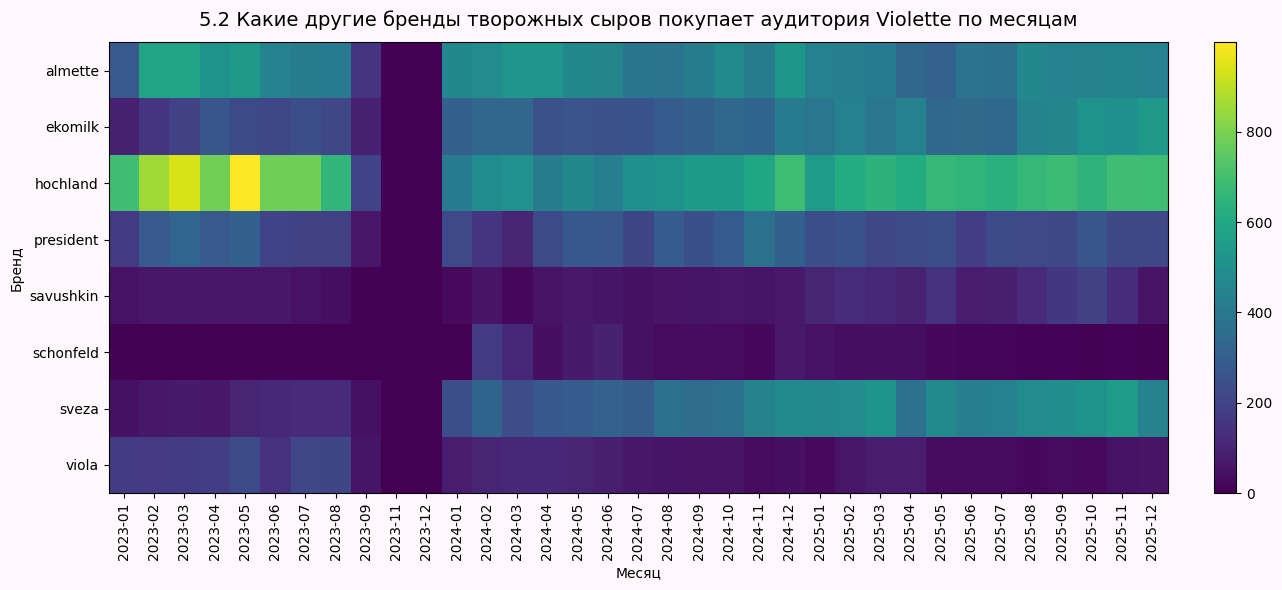

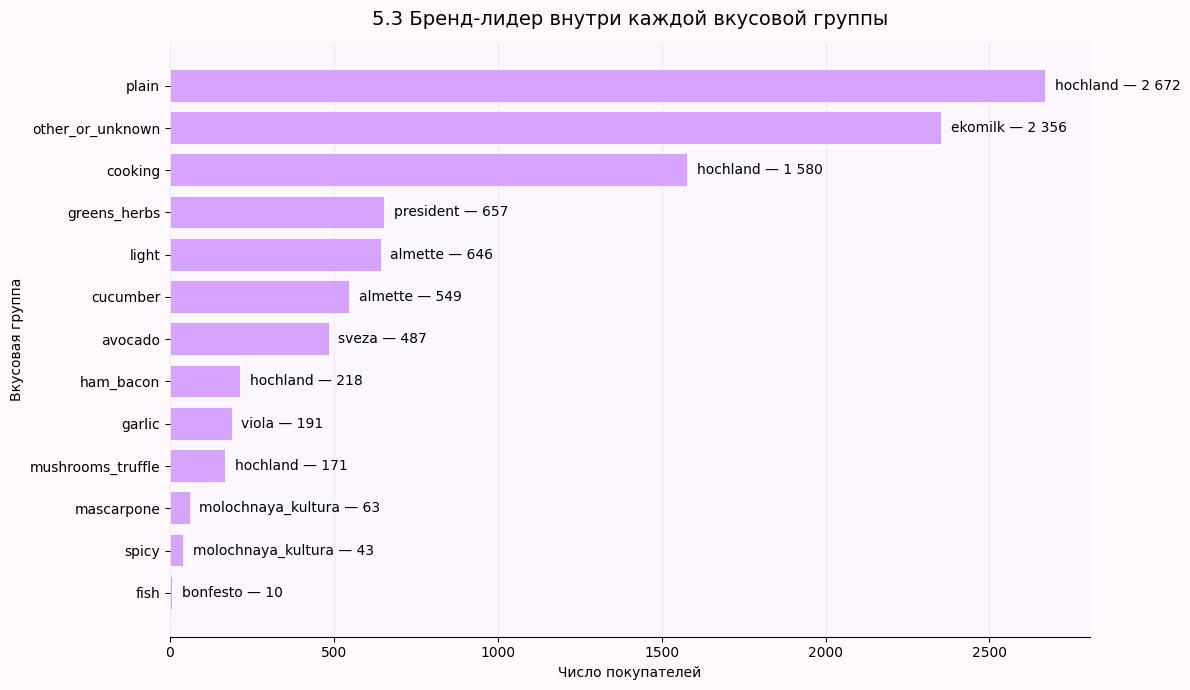

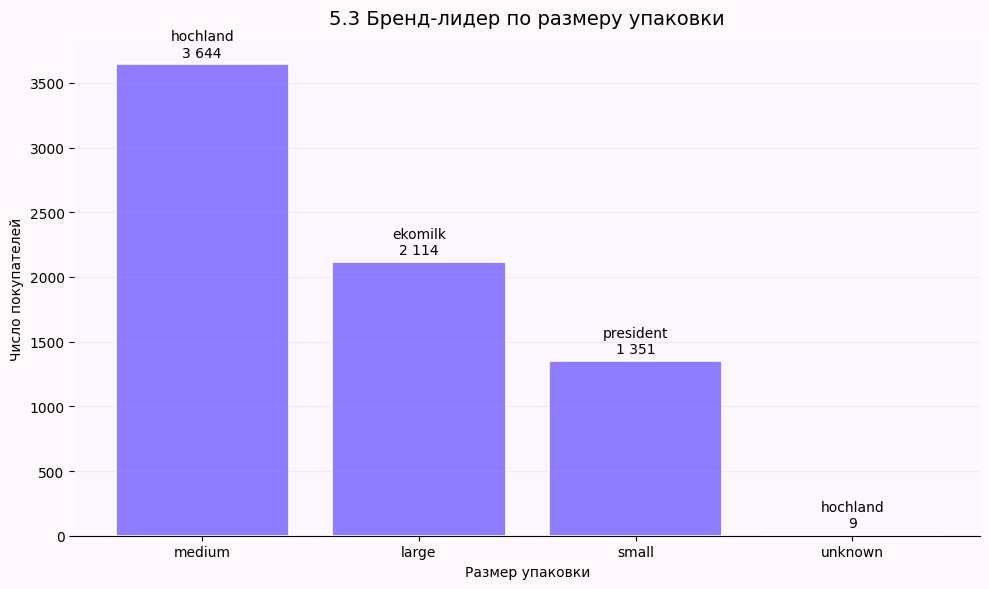

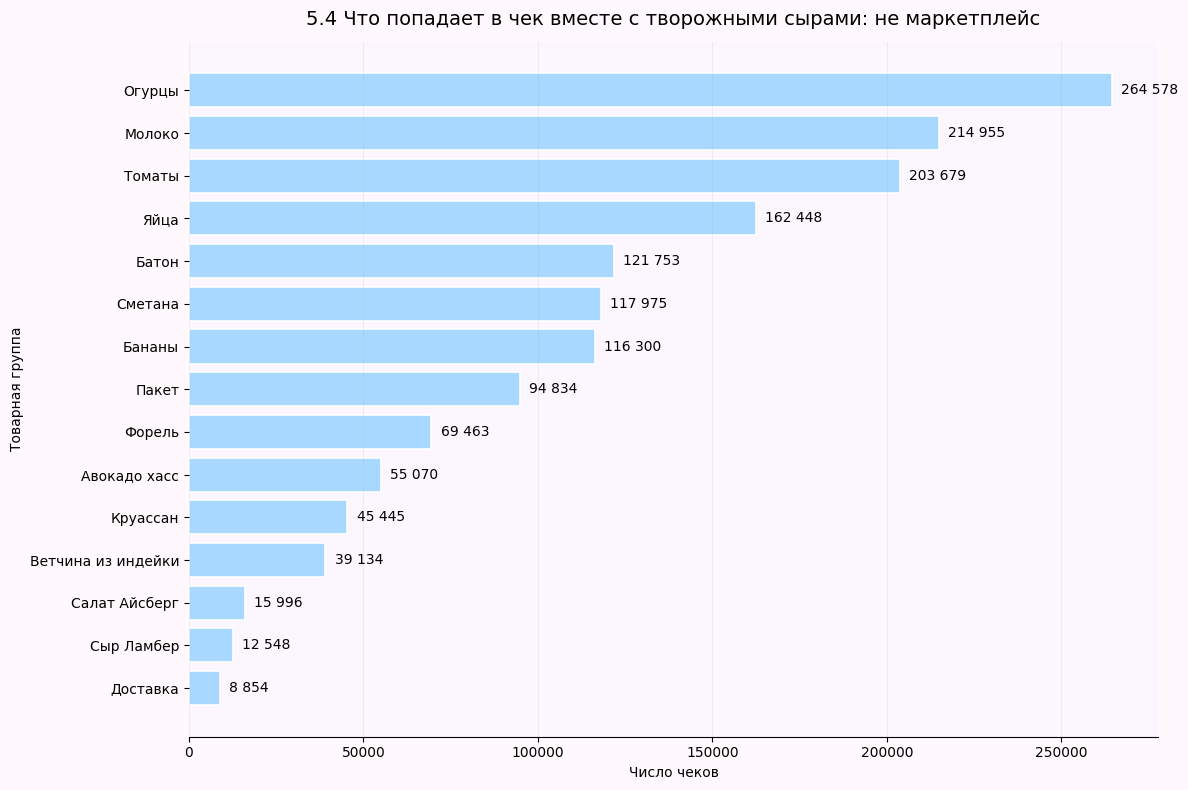

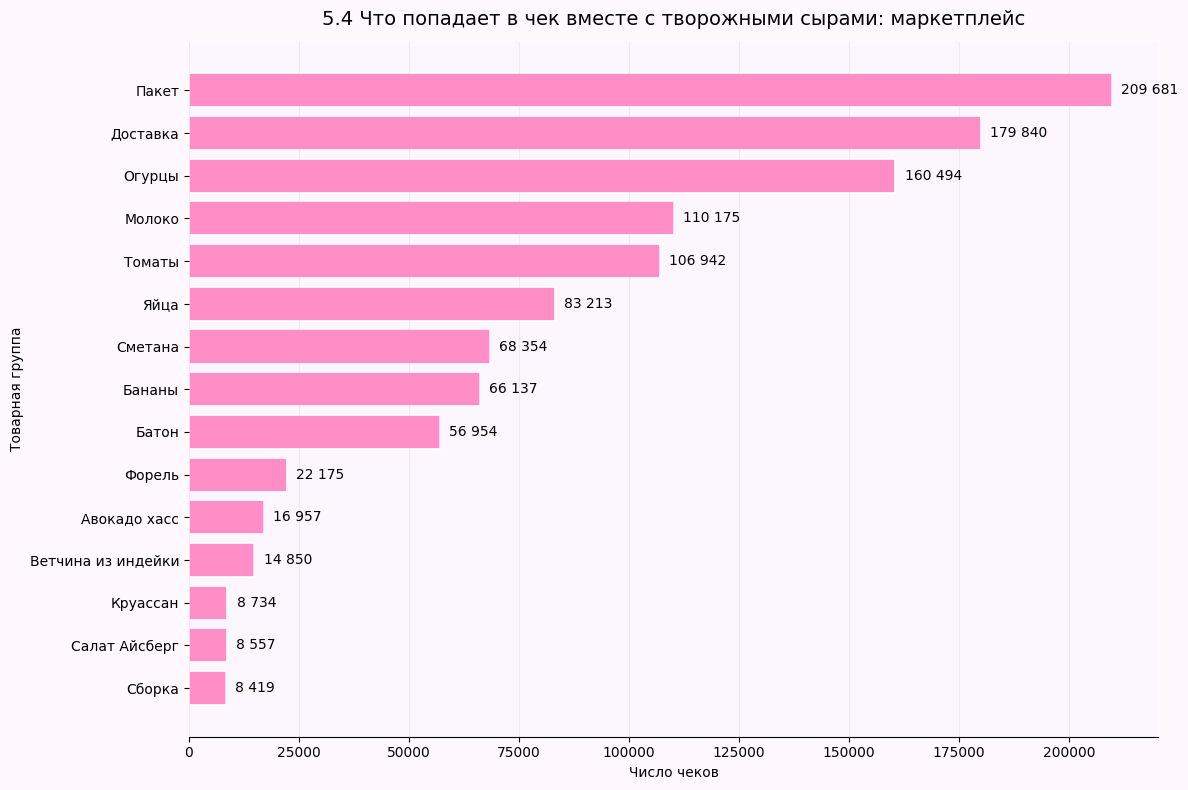

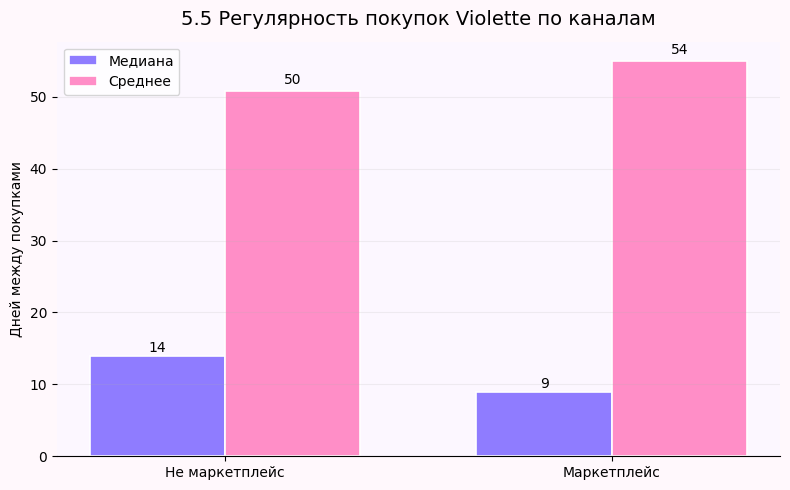

In [75]:
# -----------------------------
# Пути
# -----------------------------
BASE_DIR = Path("..") / "data"
OUT_DIR = BASE_DIR / "task_outputs"
PLOTS_DIR = OUT_DIR / "plots"
CSV_DIR = OUT_DIR / "csv"
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

# -----------------------------
# Цвета
# -----------------------------
PINK = "#ff8ec7"
PURPLE = "#8f7cff"
LILAC = "#d6a4ff"
BLUE = "#a8d8ff"
BG_FIG = "#fff8fc"
BG_AX = "#fcf7ff"

# -----------------------------
# Вспомогательные функции
# -----------------------------
def style_ax_h(ax):
    ax.grid(axis="x", alpha=0.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.set_facecolor(BG_AX)

def style_ax_v(ax):
    ax.grid(axis="y", alpha=0.18)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["left"].set_visible(False)
    ax.set_facecolor(BG_AX)

def add_bar_labels_h(ax, bars):
    widths = [b.get_width() for b in bars]
    xmax = max(widths) if widths else 0
    for bar in bars:
        val = bar.get_width()
        ax.text(
            val + xmax * 0.01,
            bar.get_y() + bar.get_height() / 2,
            f"{int(val):,}".replace(",", " "),
            va="center",
            fontsize=10
        )

def add_bar_labels_v(ax, bars):
    heights = [b.get_height() for b in bars]
    ymax = max(heights) if heights else 0
    for bar in bars:
        val = bar.get_height()
        ax.text(
            bar.get_x() + bar.get_width() / 2,
            val + ymax * 0.01,
            f"{int(val):,}".replace(",", " "),
            ha="center",
            va="bottom",
            fontsize=10
        )

# =========================================================
# 5.1 Какие другие бренды творожных сыров покупает аудитория Violette
# =========================================================
switch_market = pl.read_csv(CSV_DIR / "task5_switch_rank_by_marketplace.csv")

market_false = (
    switch_market
    .filter(pl.col("is_marketplace") == False)
    .head(10)
    .to_pandas()
)

market_true = (
    switch_market
    .filter(pl.col("is_marketplace") == True)
    .head(10)
    .to_pandas()
)

# Не маркетплейс
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(BG_FIG)
bars = ax.barh(
    market_false["brand"][::-1],
    market_false["n_buyers"][::-1],
    color=BLUE,
    edgecolor="white",
    linewidth=1.2
)
add_bar_labels_h(ax, bars)
ax.set_title("5.1 Какие другие бренды творожных сыров покупает аудитория Violette: не маркетплейс", fontsize=14, pad=12)
ax.set_xlabel("Число покупателей")
ax.set_ylabel("Бренд")
style_ax_h(ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "task5_1_other_brands_non_marketplace.png", dpi=220, bbox_inches="tight")
plt.show()

# Маркетплейс
fig, ax = plt.subplots(figsize=(11, 7))
fig.patch.set_facecolor(BG_FIG)
bars = ax.barh(
    market_true["brand"][::-1],
    market_true["n_buyers"][::-1],
    color=PINK,
    edgecolor="white",
    linewidth=1.2
)
add_bar_labels_h(ax, bars)
ax.set_title("5.1 Какие другие бренды творожных сыров покупает аудитория Violette: маркетплейс", fontsize=14, pad=12)
ax.set_xlabel("Число покупателей")
ax.set_ylabel("Бренд")
style_ax_h(ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "task5_1_other_brands_marketplace.png", dpi=220, bbox_inches="tight")
plt.show()

# =========================================================
# 5.2 Какие другие бренды творожных сыров покупает аудитория Violette по месяцам
# =========================================================
switch_month = pl.read_csv(CSV_DIR / "task5_switch_rank_by_month.csv")

top_month_brands = (
    switch_month
    .group_by("brand")
    .agg(pl.col("n_buyers").sum().alias("total_buyers"))
    .sort("total_buyers", descending=True)
    .head(8)
    .select("brand")
)

switch_month_top = switch_month.join(top_month_brands, on="brand", how="inner")

months = (
    switch_month_top
    .select("year_month")
    .unique()
    .sort("year_month")["year_month"]
    .to_list()
)

heat_df = (
    switch_month_top
    .pivot(index="brand", on="year_month", values="n_buyers", aggregate_function="sum")
    .fill_null(0)
    .sort("brand")
)

brands = heat_df["brand"].to_list()
heat_matrix = heat_df.select(months).to_numpy()

fig, ax = plt.subplots(figsize=(13, 6))
fig.patch.set_facecolor(BG_FIG)
im = ax.imshow(heat_matrix, aspect="auto")
ax.set_title("5.2 Какие другие бренды творожных сыров покупает аудитория Violette по месяцам", fontsize=14, pad=12)
ax.set_xticks(np.arange(len(months)))
ax.set_xticklabels(months, rotation=90)
ax.set_yticks(np.arange(len(brands)))
ax.set_yticklabels(brands)
ax.set_xlabel("Месяц")
ax.set_ylabel("Бренд")
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "task5_2_other_brands_by_month.png", dpi=220, bbox_inches="tight")
plt.show()

# =========================================================
# 5.3 Бренд-лидер внутри вкусовой группы и по размеру упаковки
# =========================================================
switch_flavor = pl.read_csv(CSV_DIR / "task5_switch_rank_by_flavor.csv")
switch_pack = pl.read_csv(CSV_DIR / "task5_switch_rank_by_pack.csv")

flavor_top = (
    switch_flavor
    .group_by("flavor_group")
    .head(1)
    .sort("n_buyers", descending=True)
    .to_pandas()
)

pack_top = (
    switch_pack
    .group_by("pack_bucket")
    .head(1)
    .sort("n_buyers", descending=True)
    .to_pandas()
)

# По вкусам
fig, ax = plt.subplots(figsize=(12, 7))
fig.patch.set_facecolor(BG_FIG)
bars = ax.barh(
    flavor_top["flavor_group"][::-1],
    flavor_top["n_buyers"][::-1],
    color=LILAC,
    edgecolor="white",
    linewidth=1.2
)

for bar, val, brand in zip(
    bars,
    flavor_top["n_buyers"][::-1],
    flavor_top["brand"][::-1]
):
    ax.text(
        bar.get_width() + max(flavor_top["n_buyers"]) * 0.01,
        bar.get_y() + bar.get_height() / 2,
        f"{brand} — {int(val):,}".replace(",", " "),
        va="center",
        fontsize=10
    )

ax.set_title("5.3 Бренд-лидер внутри каждой вкусовой группы", fontsize=14, pad=12)
ax.set_xlabel("Число покупателей")
ax.set_ylabel("Вкусовая группа")
style_ax_h(ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "task5_3_brand_leader_by_flavor.png", dpi=220, bbox_inches="tight")
plt.show()

# По размеру упаковки
fig, ax = plt.subplots(figsize=(10, 6))
fig.patch.set_facecolor(BG_FIG)
bars = ax.bar(
    pack_top["pack_bucket"],
    pack_top["n_buyers"],
    color=PURPLE,
    edgecolor="white",
    linewidth=1.2
)

for bar, val, brand in zip(
    bars,
    pack_top["n_buyers"],
    pack_top["brand"]
):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + max(pack_top["n_buyers"]) * 0.01,
        f"{brand}\n{int(val):,}".replace(",", " "),
        ha="center",
        va="bottom",
        fontsize=10
    )

ax.set_title("5.3 Бренд-лидер по размеру упаковки", fontsize=14, pad=12)
ax.set_xlabel("Размер упаковки")
ax.set_ylabel("Число покупателей")
style_ax_v(ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "task5_3_brand_leader_by_pack.png", dpi=220, bbox_inches="tight")
plt.show()

# =========================================================
# 5.4 Что попадает в чек вместе с творожными сырами:
# группируем товары в понятные группы
# =========================================================
copurchase_mp = pl.read_csv(CSV_DIR / "task5_copurchase_by_marketplace.csv")

copurchase_grouped = (
    copurchase_mp
    .with_columns(
        pl.col("product_name_clean")
        .str.to_lowercase()
        .str.replace_all(r"[,:;.!()]+", " ")
        .str.replace_all(r"\s+", " ")
        .str.strip_chars()
        .alias("product_name_norm")
    )
    .with_columns(
        pl.when(pl.col("product_name_norm").str.contains("сметан"))
        .then(pl.lit("Сметана"))

        .when(pl.col("product_name_norm").str.contains("молоко"))
        .then(pl.lit("Молоко"))

        .when(pl.col("product_name_norm").str.contains("яйц"))
        .then(pl.lit("Яйца"))

        .when(pl.col("product_name_norm").str.contains("банан"))
        .then(pl.lit("Бананы"))

        .when(
            pl.col("product_name_norm").str.contains("авокадо")
            & pl.col("product_name_norm").str.contains("хасс")
        )
        .then(pl.lit("Авокадо хасс"))

        .when(pl.col("product_name_norm").str.contains("огур"))
        .then(pl.lit("Огурцы"))

        .when(pl.col("product_name_norm").str.contains("томат") | pl.col("product_name_norm").str.contains("помид"))
        .then(pl.lit("Томаты"))

        .when(
            pl.col("product_name_norm").str.contains("ветчина")
            & pl.col("product_name_norm").str.contains("индейк")
        )
        .then(pl.lit("Ветчина из индейки"))

        .when(pl.col("product_name_norm").str.contains("форел"))
        .then(pl.lit("Форель"))

        .when(pl.col("product_name_norm").str.contains("батон"))
        .then(pl.lit("Батон"))

        .when(pl.col("product_name_norm").str.contains("круассан"))
        .then(pl.lit("Круассан"))

        .when(pl.col("product_name_norm").str.contains("сыр ламбер"))
        .then(pl.lit("Сыр Ламбер"))

        .when(pl.col("product_name_norm").str.contains("салат айсберг"))
        .then(pl.lit("Салат Айсберг"))

        .when(pl.col("product_name_norm").str.contains("доставка"))
        .then(pl.lit("Доставка"))

        .when(pl.col("product_name_norm").str.contains("пакет"))
        .then(pl.lit("Пакет"))

        .when(pl.col("product_name_norm").str.contains("сборка"))
        .then(pl.lit("Сборка"))

        .otherwise(pl.col("product_name_clean"))
        .alias("product_group")
    )
    .group_by(["is_marketplace", "product_group"])
    .agg(pl.col("n_checks").sum().alias("n_checks"))
    .sort(["is_marketplace", "n_checks"], descending=[False, True])
)

copurchase_grouped.write_csv(CSV_DIR / "task5_copurchase_by_marketplace_grouped.csv")

cp_false = (
    copurchase_grouped
    .filter(pl.col("is_marketplace") == False)
    .head(15)
    .to_pandas()
)

cp_true = (
    copurchase_grouped
    .filter(pl.col("is_marketplace") == True)
    .head(15)
    .to_pandas()
)

# Не маркетплейс
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG_FIG)
bars = ax.barh(
    cp_false["product_group"][::-1],
    cp_false["n_checks"][::-1],
    color=BLUE,
    edgecolor="white",
    linewidth=1.2
)
add_bar_labels_h(ax, bars)
ax.set_title("5.4 Что попадает в чек вместе с творожными сырами: не маркетплейс", fontsize=14, pad=12)
ax.set_xlabel("Число чеков")
ax.set_ylabel("Товарная группа")
style_ax_h(ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "task5_4_copurchase_non_marketplace_grouped.png", dpi=220, bbox_inches="tight")
plt.show()

# Маркетплейс
fig, ax = plt.subplots(figsize=(12, 8))
fig.patch.set_facecolor(BG_FIG)
bars = ax.barh(
    cp_true["product_group"][::-1],
    cp_true["n_checks"][::-1],
    color=PINK,
    edgecolor="white",
    linewidth=1.2
)
add_bar_labels_h(ax, bars)
ax.set_title("5.4 Что попадает в чек вместе с творожными сырами: маркетплейс", fontsize=14, pad=12)
ax.set_xlabel("Число чеков")
ax.set_ylabel("Товарная группа")
style_ax_h(ax)
plt.tight_layout()
plt.savefig(PLOTS_DIR / "task5_4_copurchase_marketplace_grouped.png", dpi=220, bbox_inches="tight")
plt.show()

# =========================================================
# 5.5 Регулярность покупок Violette по каналам
# =========================================================
reg_mp = pl.read_csv(CSV_DIR / "task5_regularity_by_marketplace.csv").to_pandas()

reg_mp["channel"] = reg_mp["is_marketplace"].map({
    False: "Не маркетплейс",
    True: "Маркетплейс",
    0: "Не маркетплейс",
    1: "Маркетплейс"
})

fig, ax = plt.subplots(figsize=(8, 5))
fig.patch.set_facecolor(BG_FIG)
ax.set_facecolor(BG_AX)

x = np.arange(len(reg_mp))
width = 0.35

bars1 = ax.bar(
    x - width/2,
    reg_mp["median_gap_days"],
    width,
    label="Медиана",
    color=PURPLE,
    edgecolor="white",
    linewidth=1.2
)

bars2 = ax.bar(
    x + width/2,
    reg_mp["mean_gap_days"],
    width,
    label="Среднее",
    color=PINK,
    edgecolor="white",
    linewidth=1.2
)

ax.set_xticks(x)
ax.set_xticklabels(reg_mp["channel"])
ax.set_title("5.5 Регулярность покупок Violette по каналам", fontsize=14, pad=12)
ax.set_ylabel("Дней между покупками")
ax.legend()
style_ax_v(ax)

add_bar_labels_v(ax, bars1)
add_bar_labels_v(ax, bars2)

plt.tight_layout()
plt.savefig(PLOTS_DIR / "task5_5_regularity_by_marketplace.png", dpi=220, bbox_inches="tight")
plt.show()

В задании 5 анализ из пунктов 1–4 дополнительно рассматривается в нескольких разрезах. Сначала смотрится, какие другие бренды творожных сыров встречаются в покупках аудитории Violette отдельно для маркетплейсов и немаркетплейсов. Затем тот же показатель рассматривается по месяцам, чтобы увидеть, как меняется присутствие альтернативных брендов во времени. Отдельно анализируется разрез по ассортиментным характеристикам: по вкусовым группам и по размеру упаковки, где для каждой группы показывается бренд-лидер по числу покупателей.

Далее для чекового анализа рассматривается, какие товары чаще всего попадают в чек вместе с творожными сырами, тоже отдельно по каналам. При этом для удобства интерпретации близкие варианты одного и того же продукта дополнительно объединяются в укрупнённые товарные группы, например молоко, сметана, яйца, бананы, но разные продукты между собой не смешиваются, поэтому огурцы, томаты, салаты и другие позиции остаются отдельными группами.

Наконец, в разрезе каналов рассматривается регулярность покупок Violette: сравниваются интервалы между покупками на маркетплейсах и вне маркетплейсов. Для этого используются медианные и средние промежутки между соседними покупками, чтобы отдельно видеть типичный интервал и более общую картину по каналу.

### Некоторые проверки для финального анализа:

In [77]:
def E(df):
    return df.collect() if isinstance(df, pl.LazyFrame) else df

Очистка и дедуп

In [78]:
raw_qc = E(
    lf_typed.select(
        pl.len().alias("raw_rows"),
        pl.col("buyer_id").n_unique().alias("raw_buyers"),
        pl.col("check_id").n_unique().alias("raw_checks"),
        pl.col("qty").is_null().sum().alias("qty_null_rows"),
        pl.col("amount").is_null().sum().alias("amount_null_rows"),
        (pl.col("qty") <= 0).fill_null(False).sum().alias("qty_le_0_rows"),
        (pl.col("amount") < 0).fill_null(False).sum().alias("amount_lt_0_rows"),
        (pl.col("amount") == 0).fill_null(False).sum().alias("amount_eq_0_rows"),
        (pl.col("qty") == 0.001).fill_null(False).sum().alias("qty_eq_0001_rows"),
    )
).to_dicts()[0]

clean_qc = E(
    lf_clean.select(
        pl.len().alias("clean_rows"),
        pl.col("buyer_id").n_unique().alias("clean_buyers"),
        pl.col("check_id").n_unique().alias("clean_checks"),
    )
).to_dicts()[0]

items_qc = E(
    lf_items.select(
        pl.len().alias("items_rows"),
        pl.col("buyer_id").n_unique().alias("items_buyers"),
        pl.col("check_id").n_unique().alias("items_checks"),
        pl.col("n_rows_merged").max().alias("max_rows_merged_in_one_item"),
    )
).to_dicts()[0]

pd.DataFrame([
    {"metric": "raw_rows", "value": raw_qc["raw_rows"]},
    {"metric": "raw_buyers", "value": raw_qc["raw_buyers"]},
    {"metric": "raw_checks", "value": raw_qc["raw_checks"]},
    {"metric": "qty_null_rows", "value": raw_qc["qty_null_rows"]},
    {"metric": "amount_null_rows", "value": raw_qc["amount_null_rows"]},
    {"metric": "qty_le_0_rows", "value": raw_qc["qty_le_0_rows"]},
    {"metric": "amount_lt_0_rows", "value": raw_qc["amount_lt_0_rows"]},
    {"metric": "amount_eq_0_rows", "value": raw_qc["amount_eq_0_rows"]},
    {"metric": "qty_eq_0001_rows", "value": raw_qc["qty_eq_0001_rows"]},
    {"metric": "clean_rows", "value": clean_qc["clean_rows"]},
    {"metric": "clean_buyers", "value": clean_qc["clean_buyers"]},
    {"metric": "clean_checks", "value": clean_qc["clean_checks"]},
    {"metric": "items_rows_after_incheck_agg", "value": items_qc["items_rows"]},
    {"metric": "items_buyers", "value": items_qc["items_buyers"]},
    {"metric": "items_checks", "value": items_qc["items_checks"]},
    {"metric": "rows_removed_by_cleaning", "value": raw_qc["raw_rows"] - clean_qc["clean_rows"]},
    {"metric": "rows_reduced_by_incheck_agg", "value": clean_qc["clean_rows"] - items_qc["items_rows"]},
    {"metric": "max_rows_merged_in_one_item", "value": items_qc["max_rows_merged_in_one_item"]},
])

,metric,value
0,raw_rows,16509165
1,raw_buyers,35175
2,raw_checks,1549482
3,qty_null_rows,109
4,amount_null_rows,0
5,qty_le_0_rows,0
6,amount_lt_0_rows,0
7,amount_eq_0_rows,33395
8,qty_eq_0001_rows,2849
9,clean_rows,16509056


Топ товаров, которые чаще всего схлопывались внутри чека

In [79]:
E(
    lf_clean
    .group_by(["check_id", "product_name"])
    .len()
    .filter(pl.col("len") > 1)
    .group_by("product_name")
    .agg(
        pl.len().alias("n_checks_with_repeat_inside"),
        (pl.col("len") - 1).sum().alias("extra_rows_merged"),
        pl.col("len").max().alias("max_same_product_rows_in_one_check"),
    )
    .sort(["extra_rows_merged", "n_checks_with_repeat_inside"], descending=True)
    .head(20)
)

product_name,n_checks_with_repeat_inside,extra_rows_merged,max_same_product_rows_in_one_check
str,u32,u32,u32
"""Пакет-майка 43х68см 20кг""",2327,2327,2
"""Пакет-майка""",1313,1313,2
"""Пакет-майка 35+18х61""",691,691,2
"""Сыр творожный Экомилк 60% 350г""",681,681,2
"""сырок творожный в бельгийском шоколаде, с вареной сгущенкой, 26%, 40 г""",632,632,2
"""Творожный сыр Almette, мягкий, сливочный, 60%, 150 г""",481,481,2
"""Бананы спелые""",436,436,2
"""Круассан , на сливочном масле, без начинки, 50 г""",389,389,2
"""круассан на сливочном масле, 50 г""",374,374,2


Покрытие обогащения

In [80]:
coverage = E(
    line_fact.select(
        pl.len().alias("rows_total"),
        pl.col("is_cream_cheese").fill_null(False).sum().alias("cream_rows"),
        pl.col("is_target_violette").fill_null(False).sum().alias("target_rows"),
        pl.col("brand").is_not_null().sum().alias("brand_filled_rows"),
        pl.col("pack_size_g").is_not_null().sum().alias("pack_filled_rows"),
        pl.col("flavor_group").is_not_null().sum().alias("flavor_filled_rows"),
    )
).to_dicts()[0]

cream_cov = E(
    line_fact
    .filter(pl.col("is_cream_cheese").fill_null(False))
    .select(
        pl.len().alias("cream_rows"),
        (pl.col("brand") == "unknown").fill_null(False).sum().alias("brand_unknown_rows"),
        (pl.col("brand") == "no_brand").fill_null(False).sum().alias("brand_no_brand_rows"),
        pl.col("pack_size_g").is_not_null().sum().alias("pack_filled_rows"),
        pl.col("flavor_group").is_not_null().sum().alias("flavor_filled_rows"),
    )
).to_dicts()[0]

pd.DataFrame([
    {"metric": "rows_total", "value": coverage["rows_total"]},
    {"metric": "cream_rows", "value": coverage["cream_rows"]},
    {"metric": "target_rows", "value": coverage["target_rows"]},
    {"metric": "brand_filled_rows", "value": coverage["brand_filled_rows"]},
    {"metric": "pack_filled_rows", "value": coverage["pack_filled_rows"]},
    {"metric": "flavor_filled_rows", "value": coverage["flavor_filled_rows"]},
    {"metric": "share_brand_filled_all_rows", "value": coverage["brand_filled_rows"] / coverage["rows_total"]},
    {"metric": "share_pack_filled_all_rows", "value": coverage["pack_filled_rows"] / coverage["rows_total"]},
    {"metric": "share_flavor_filled_all_rows", "value": coverage["flavor_filled_rows"] / coverage["rows_total"]},
    {"metric": "brand_unknown_rows_within_cream", "value": cream_cov["brand_unknown_rows"]},
    {"metric": "brand_no_brand_rows_within_cream", "value": cream_cov["brand_no_brand_rows"]},
    {"metric": "share_brand_unknown_within_cream", "value": cream_cov["brand_unknown_rows"] / cream_cov["cream_rows"]},
    {"metric": "share_brand_no_brand_within_cream", "value": cream_cov["brand_no_brand_rows"] / cream_cov["cream_rows"]},
    {"metric": "share_pack_filled_within_cream", "value": cream_cov["pack_filled_rows"] / cream_cov["cream_rows"]},
    {"metric": "share_flavor_filled_within_cream", "value": cream_cov["flavor_filled_rows"] / cream_cov["cream_rows"]},
])

,metric,value
0,rows_total,1.650916e+07
1,cream_rows,1.102649e+06
2,target_rows,2.659300e+04
3,brand_filled_rows,1.102649e+06
4,pack_filled_rows,1.098929e+06
5,flavor_filled_rows,1.102649e+06
6,share_brand_filled_all_rows,6.679011e-02
7,share_pack_filled_all_rows,6.656478e-02
8,share_flavor_filled_all_rows,6.679011e-02
9,brand_unknown_rows_within_cream,1.860000e+02


Эффект p99-обрезки

In [81]:
p99_vals = E(
    lf_items.select(
        pl.col("amount").quantile(0.99).alias("amount_p99"),
        pl.col("qty").quantile(0.99).alias("qty_p99"),
        pl.len().alias("rows_total"),
    )
).to_dicts()[0]

amount_p99 = float(p99_vals["amount_p99"])
qty_p99 = float(p99_vals["qty_p99"])

tail_rows = E(
    lf_items.select(
        (pl.col("amount") > amount_p99).sum().alias("rows_amount_gt_p99"),
        (pl.col("qty") > qty_p99).sum().alias("rows_qty_gt_p99"),
        ((pl.col("amount") > amount_p99) | (pl.col("qty") > qty_p99)).sum().alias("rows_removed_by_p99_union"),
    )
).to_dicts()[0]

pd.DataFrame([
    {"metric": "amount_p99", "value": amount_p99},
    {"metric": "qty_p99", "value": qty_p99},
    {"metric": "rows_total", "value": p99_vals["rows_total"]},
    {"metric": "rows_amount_gt_p99", "value": tail_rows["rows_amount_gt_p99"]},
    {"metric": "rows_qty_gt_p99", "value": tail_rows["rows_qty_gt_p99"]},
    {"metric": "rows_removed_by_p99_union", "value": tail_rows["rows_removed_by_p99_union"]},
    {"metric": "share_removed_by_p99_union", "value": tail_rows["rows_removed_by_p99_union"] / p99_vals["rows_total"]},
])

,metric,value
0,amount_p99,8.310000e+02
1,qty_p99,5.000000e+00
2,rows_total,1.631602e+07
3,rows_amount_gt_p99,1.630330e+05
4,rows_qty_gt_p99,1.151820e+05
5,rows_removed_by_p99_union,2.581610e+05
6,share_removed_by_p99_union,1.582254e-02


Базы для заданий

In [85]:
CSV_DIR = Path("/Users/evaeva.monsher/Desktop/karat_violette/data/task_outputs/csv")

task1 = pl.read_csv(CSV_DIR / "task1_switch_rank_overall.csv")
task2 = pl.read_csv(CSV_DIR / "task2_churn_switch_rank.csv")
task3_grouped = pl.read_csv(CSV_DIR / "task3_copurchase_products_grouped.csv")
task4_regularity = pl.read_csv(CSV_DIR / "task4_buyer_regularity.csv")
task4_segments = pl.read_csv(CSV_DIR / "task4_regularity_segments.csv")
task5_grouped = pl.read_csv(CSV_DIR / "task5_copurchase_by_marketplace_grouped.csv")
task5_regularity_marketplace = pl.read_csv(CSV_DIR / "task5_regularity_by_marketplace.csv")
task5_month = pl.read_csv(CSV_DIR / "task5_switch_rank_by_month.csv")

Базы по заданиям и базы по каналам.

In [86]:
violette_buyer_base = int(task1["violette_buyer_base"][0])
churn_buyer_base = int(task2["churn_buyer_base"][0])
cream_check_base = int(task3_grouped["cream_check_base"][0])
repeat_violette_buyers = task4_regularity.height
one_time_violette_buyers = violette_buyer_base - repeat_violette_buyers

pd.DataFrame([
    {"metric": "violette_buyer_base_task1", "value": violette_buyer_base},
    {"metric": "churn_buyer_base_task2", "value": churn_buyer_base},
    {"metric": "cream_check_base_task3", "value": cream_check_base},
    {"metric": "repeat_violette_buyers_task4", "value": repeat_violette_buyers},
    {"metric": "one_time_violette_buyers_task4", "value": one_time_violette_buyers},
    {"metric": "one_time_share_of_violette_base", "value": one_time_violette_buyers / violette_buyer_base},
])

,metric,value
0,violette_buyer_base_task1,4.858000e+03
1,churn_buyer_base_task2,8.620000e+02
2,cream_check_base_task3,1.026222e+06
3,repeat_violette_buyers_task4,3.049000e+03
4,one_time_violette_buyers_task4,1.809000e+03
5,one_time_share_of_violette_base,3.723755e-01


In [87]:
E(
    lf_tasks
    .group_by("is_marketplace")
    .agg(
        pl.when(pl.col("is_target_violette").fill_null(False)).then(pl.col("buyer_id")).otherwise(None).n_unique().alias("violette_buyers"),
        pl.when(pl.col("is_target_violette").fill_null(False)).then(pl.col("check_id")).otherwise(None).n_unique().alias("violette_checks"),
        pl.when(pl.col("is_cream_cheese").fill_null(False)).then(pl.col("buyer_id")).otherwise(None).n_unique().alias("cream_buyers"),
        pl.when(pl.col("is_cream_cheese").fill_null(False)).then(pl.col("check_id")).otherwise(None).n_unique().alias("cream_checks"),
        pl.col("buyer_id").n_unique().alias("all_buyers"),
        pl.col("check_id").n_unique().alias("all_checks"),
    )
    .sort("is_marketplace")
)

is_marketplace,violette_buyers,violette_checks,cream_buyers,cream_checks,all_buyers,all_checks
bool,u32,u32,u32,u32,u32,u32
false,3216,12014,30959,742652,32802,1066307
true,2850,10341,15219,283572,16520,481668


Проверка service items по каналам

Для маркетплейсов / немаркетплейсов.

In [89]:
task5_grouped = pl.read_csv(CSV_DIR / "task5_copurchase_by_marketplace_grouped.csv")

In [90]:
service_groups = ["Пакет", "Доставка", "Сборка"]

E(
    task5_grouped
    .filter(pl.col("product_group").is_in(service_groups))
    .sort(["is_marketplace", "n_checks"], descending=[False, True])
)

is_marketplace,product_group,n_checks
bool,str,i64
false,"""Пакет""",94834
false,"""Доставка""",8854
false,"""Сборка""",8565
true,"""Пакет""",209681
true,"""Доставка""",179840
true,"""Сборка""",8419


Проверка регулярности

In [91]:
task4_regularity.select(
    pl.len().alias("repeat_buyers"),
    pl.col("median_gap_days").median().alias("median_of_median_gaps"),
    pl.col("median_gap_days").quantile(0.25).alias("median_gap_p25"),
    pl.col("median_gap_days").quantile(0.75).alias("median_gap_p75"),
    pl.col("mean_gap_days").mean().alias("mean_of_mean_gaps"),
    pl.col("n_gaps").sum().alias("total_gaps"),
)

repeat_buyers,median_of_median_gaps,median_gap_p25,median_gap_p75,mean_of_mean_gaps,total_gaps
u32,f64,f64,f64,f64,i64
3049,23.5,9.0,65.5,95.035389,17496


In [92]:
task4_segments.sort("n_buyers", descending=True)

frequency_segment,n_buyers
str,i64
"""high_freq""",1134
"""rare""",805
"""monthly_like""",629
"""low_freq""",481


Проверка пропуска месяцев

Для истории с 2023-10.

In [95]:
task5_month = pl.read_csv(CSV_DIR / "task5_switch_rank_by_month.csv")

all_months = sorted(
    E(
        lf_tasks
        .select("year_month")
        .drop_nulls()
        .unique()
    )["year_month"].to_list()
)

heatmap_months = sorted(task5_month["year_month"].unique().to_list())

start_month = min(all_months)
end_month = max(all_months)

expected_months = pd.period_range(start=start_month, end=end_month, freq="M").astype(str).tolist()

month_diag = pd.DataFrame({"year_month": expected_months})
month_diag["in_lf_tasks"] = month_diag["year_month"].isin(all_months)
month_diag["in_task5_heatmap"] = month_diag["year_month"].isin(heatmap_months)

month_diag

,year_month,in_lf_tasks,in_task5_heatmap
0,2023-01,True,True
1,2023-02,True,True
2,2023-03,True,True
3,2023-04,True,True
4,2023-05,True,True
5,2023-06,True,True
6,2023-07,True,True
7,2023-08,True,True
8,2023-09,True,True
9,2023-10,True,False
